# 03. 전처리 파이프라인 (Preprocessing)

`01.data_nogada`에서 확인한 것들과 `MD/` 폴더 문서를 코드로 구현한다.

- `04. 전처리 방법론 고민(기상요소)` → 풍속·풍향 벡터 변환, 습윤공기 밀도, 비습 → 수증기압
- `05. 전처리 방법 고민(LDAPS 데이터)` → 물리한계 기반 품질검사, 결측률 구간별 처리
- `06. 데이터 파이프라인 개선` → 권장 파이프라인 10단계, 현재 코드에서 바로 고칠 다섯 가지

| Step | 내용 |
|---|---|
| 1 | 원본 로드 및 데이터 계약 검사 |
| 2 | 시간·단위·컬럼 형식 통일 |
| 3 | 결측 현황 확인 |
| 4 | 물리한계 기반 이상치 탐지 (플래그) |
| 5 | 이상치 NaN 변환 및 QC 비트 코드 |
| 6 | 결측 패턴·연속 길이 분석 |
| 7 | 단기 결측 보간 |
| 8 | SCADA·LDAPS 파생변수 생성 |
| 9 | 10분 SCADA를 시간 단위로 집계 |
| 10 | 예보시각 기준 결합 및 검증 |
| 11 | prep/ 폴더에 저장 |

- 대상: `ldaps_train.csv`, `scada_vestas_train.csv`, `scada_unison_train.csv`
- 결과: `prep/` 폴더에 CSV로 저장해 모델링에서 바로 받아쓸 수 있는 형태로 만든다

**노트북 작성 원칙**

1. SCADA는 **LDAPS 보정·품질진단용**이다. 평가 기간에는 SCADA가 없다
2. LDAPS 16격자를 통째로 평균내지 않고 **그룹별 공간 가중 버전**으로 만든다 (단순평균 버전도 같이 저장해 비교)
3. 결측·정지·출력제한·센서 오류를 같은 이상치로 뭉개지 않고 **플래그로 구분**한다
4. 이상치는 지우기 전에 플래그를 남긴다. 특히 **발전량 0은 결측으로 바꾸지 않는다**

## Step 0. 라이브러리와 상수

`1.05`, `min_count=6`, IDW 이웃 4개처럼 나중에 바꿔가며 실험할 값을 코드 중간중간에 흘려놓으면
어디를 고쳐야 하는지 찾기 힘들어진다. 그래서 임계값은 전부 여기 한 곳에 모은다.

In [1]:
# Step 0. 라이브러리

import re
# 터빈 좌표가 도·분·초 문자열로 적혀 있어 정규식으로 숫자만 뽑는다
from pathlib import Path
from typing import Dict, List, Tuple
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --- 경로 ---
PROJECT_ROOT = Path(".")
# 노트북을 저장소 루트에서 실행하는 것을 전제로 한다
PREP_DIR = PROJECT_ROOT / "prep"
# 이 노트북의 결과물(전처리 완료 CSV)을 저장할 폴더
PREP_DIR.mkdir(exist_ok=True)
# 폴더가 없으면 만들고 있으면 그냥 넘어간다

# --- 물리 상수 (MD/04. 전처리 방법론 고민 참고) ---
R_D = 287.05
# 건조공기 기체상수 J/(kg·K)
EPSILON = 0.62197
# 건조공기/수증기 기체상수 비(Rd/Rv). 수증기압 식의 분모에 들어간다
ONE_MINUS_EPS = 0.37803
# 1 - EPSILON
RHO_STD = 1.225
# 표준 대기 공기밀도 kg/m³. 계산 결과가 현실적인지 비교하는 기준
BETZ_LIMIT = 0.593
# 베츠 한계. 바람의 운동에너지 중 이론적으로 추출 가능한 최대 비율

# --- SCADA 품질검사 임계값 ---
POWER_CAP_RATIO = 1.05
# 정격의 105%를 넘으면 센서 오류로 본다
NEG_POWER_RATIO = 0.05
# 정격의 5%보다 큰 음수는 '큰 음수'(센서·단위 오류 의심)로 따로 구분한다
FROZEN_STEPS = 18
# 같은 값이 10분 간격으로 18번(3시간) 넘게 반복되면 센서 고착을 의심한다
CUT_IN_MS = 3.0
# 컷인 풍속. V126·U136 둘 다 3 m/s (스펙 시트 확인)
HIGH_WS_MS = 5.0
# 이 정도 바람이면 당연히 발전해야 하는데 0이면 고장·정비·출력제한 후보다
WS_PHYS_MAX = 75.0
# 풍속 물리한계 상한 (05 문서의 기상청 물리한계표 AWS 기준)
DISAGREE_RATIO = 0.5
# 같은 그룹 다른 터빈 중앙값과 정격 50% 이상 벌어지면 개별 장비 이상 후보다
LOW_WS_MASK = 1.0
# 풍속이 이보다 낮으면 풍향은 의미가 약하니 방향 통계에서 빼둔다

# --- 집계·보간 규칙 (06 문서 2.2, 05 문서 결측 가이드) ---
MIN_SAMPLES_PER_HOUR = 6
# 10분값 6개가 모두 있을 때만 그 시간 발전량으로 인정한다
MIN_SAMPLES_RELAXED = 5
# 5/6만 있어도 인정하는 버전도 같이 만들어 나중에 비교한다
MAX_INTERP_STEPS = 2
# 연속 결측이 2칸(20분) 이하일 때만 보간하고 그보다 길면 손대지 않는다

# --- LDAPS 공간 매핑 (06 문서 2.5) ---
IDW_K = 4
# 터빈마다 가까운 격자 4개만 사용한다
IDW_POWER = 2.0
# 역거리 가중의 지수 (1/거리²)
EARTH_RADIUS_KM = 6371.0
# 하버사인 거리 계산에 쓰는 지구 반지름
WS_TIME_JUMP_MS = 15.0
# 1시간에 이만큼 넘게 변하면 시간 급변으로 표시한다
WS_SPACE_JUMP_MS = 10.0
# 같은 시각인데 격자 간 이만큼 벌어지면 공간 급변으로 표시한다

# --- 터빈 스펙 (INFO/V126_vs_U136_스펙비교.html) ---
SWEPT_AREA_M2 = {"V126": 12469.0, "U136": 14470.0}
# 수풍면적(m²). U136은 04 문서의 추정치(14,527) 대신 실제 스펙값을 쓴다
CUT_OUT_MS = {"V126": 22.5, "U136": 22.0}
# 컷아웃 풍속. 이 이상 불면 터빈을 세우므로 발전량 0이 정상이다
GROUP_CAP_KWH = {"kpx_group_1": 21600.0, "kpx_group_2": 21600.0, "kpx_group_3": 21000.0}
# 그룹별 1시간 설비용량(kWh)
GROUPS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]
# 그룹 이름 순서를 고정해 표·그래프에서 계속 재사용한다

# --- 그래프 설정 ---
plt.rcParams["font.family"] = "Malgun Gothic"
# 한글 라벨이 깨지지 않도록 지정
plt.rcParams["axes.unicode_minus"] = False
# 마이너스(-) 기호가 깨지는 것을 방지
pd.set_option("display.max_columns", 50)
# 표를 볼 때 컬럼이 잘리지 않게 넉넉히 잡는다

## Step 1. 원본 로드 및 데이터 계약 검사

전처리를 시작하기 전에 "내가 생각한 데이터 구조가 정말 맞나"를 먼저 확인한다.
**00시 자료를 잘못된 예보 발행일에 붙이거나 24시간 묶음이 하루씩 밀리면** 뒤 작업이 전부 무의미해진다.
시간 관련 의심은 여기서 다 끝내고 간다.

확인할 것

- 필수 컬럼이 다 있는지
- `(forecast_kst_dtm, grid_id)` 중복이 없는지
- 예보 대상 시각마다 격자가 정확히 16개인지
- 격자 좌표가 기간 내내 변하지 않는지
- `data_available_kst_dtm <= forecast_kst_dtm` 인지 (미래 정보를 당겨쓰는 일이 없어야 함)
- SCADA 시각에 중복이 없고 10분 간격이 일정한지

In [3]:
@dataclass
class WindforceDataLoader:
    """WINDFORCE 원본 데이터 로드를 담당하는 클래스

    Attributes:
        - _paths : 파일명 -> 실제 경로 레지스트리
        - _cache : 파일명 -> 로딩된 DataFrame 캐시
    """

    root: Path = PROJECT_ROOT
    # 저장소 루트 경로 (기본값)
    encoding: str = "utf-8-sig"
    # 명세서상 원본 CSV가 BOM 있는 UTF-8로 저장되어 있어 인코딩을 명시한다

    root_train: Path = field(init=False)
    root_info: Path = field(init=False)
    _paths: Dict[str, Path] = field(default_factory=dict, init=False)
    _cache: Dict[str, pd.DataFrame] = field(default_factory=dict, init=False)

    def __post_init__(self):
        """dataclass의 __init__ 실행 직후 자동 호출되는 메서드"""
        self.root_train = self.root / "TRAIN"
        self.root_info = self.root / "INFO"

        self._paths = {
            "ldaps_train": self.root_train / "ldaps_train.csv",
            # LDAPS 예보. 매시간 x 16격자 (420,864행)
            "scada_vestas_train": self.root_train / "scada_vestas_train.csv",
            # VESTAS 12기 10분 실측 (157,819행)
            "scada_unison_train": self.root_train / "scada_unison_train.csv",
            # UNISON 5기 10분 실측 (105,264행)
            "train_labels": self.root_train / "train_labels.csv",
            # KPX 그룹별 시간당 실제 발전량. Step 10에서 검증용 참조로만 읽는다
            "turbine_info": self.root_info / "info.xlsx",
            # 터빈 17기의 그룹·좌표·정격 정보
        }

    def checkPath(self) -> Dict[str, bool]:
        """등록된 모든 경로의 존재 여부를 확인하는 메서드"""
        status = {}
        for name, path in self._paths.items():
            exists = path.exists()
            status[name] = exists
            mark = "O" if exists else "X"
            print(f"{mark}  {name}: {path}")
        return status

    def load(self, name: str, force: bool = False, **kwargs) -> pd.DataFrame:
        """개별 파일을 로드하는 메서드 (캐싱 지원)

        Args:
            - name  : _paths에 등록된 파일명
            - force : True면 캐시를 무시하고 다시 읽는다
        """
        if name not in self._paths:
            raise KeyError(f"'{name}'은 등록된 파일이 아닙니다. 사용 가능: {list(self._paths.keys())}")
        if name in self._cache and not force:
            return self._cache[name]
            # LDAPS는 42만 행이라 재로딩 비용이 크다

        path = self._paths[name]
        if path.suffix == ".xlsx":
            df = pd.read_excel(path, **kwargs)
        else:
            df = pd.read_csv(path, encoding=self.encoding, **kwargs)
        self._cache[name] = df
        return df

    def __getitem__(self, name: str) -> pd.DataFrame:
        return self.load(name)
        # loader["ldaps_train"] 형태의 딕셔너리 접근을 지원한다

In [4]:
loader = WindforceDataLoader()
loader.checkPath()

O  ldaps_train: TRAIN\ldaps_train.csv
O  scada_vestas_train: TRAIN\scada_vestas_train.csv
O  scada_unison_train: TRAIN\scada_unison_train.csv
O  train_labels: TRAIN\train_labels.csv
O  turbine_info: INFO\info.xlsx


{'ldaps_train': True,
 'scada_vestas_train': True,
 'scada_unison_train': True,
 'train_labels': True,
 'turbine_info': True}

In [5]:
# 세 파일을 읽고 시간 컬럼을 진짜 날짜/시간 타입으로 바꾼다 (뒤의 모든 시간 연산이 이걸 전제로 한다)
ldaps_raw = loader["ldaps_train"].copy()
ldaps_raw["forecast_kst_dtm"] = pd.to_datetime(ldaps_raw["forecast_kst_dtm"])
# 예보 대상 시각
ldaps_raw["data_available_kst_dtm"] = pd.to_datetime(ldaps_raw["data_available_kst_dtm"])
# 예보 사용 가능 시각

vestas_raw = loader["scada_vestas_train"].copy()
vestas_raw["kst_dtm"] = pd.to_datetime(vestas_raw["kst_dtm"])
unison_raw = loader["scada_unison_train"].copy()
unison_raw["kst_dtm"] = pd.to_datetime(unison_raw["kst_dtm"])

for name, df in [("ldaps_train", ldaps_raw), ("scada_vestas_train", vestas_raw), ("scada_unison_train", unison_raw)]:
    print(f"{name}: {df.shape[0]:,}행 x {df.shape[1]}열")
    # 명세서 행 수(420,864 / 157,819 / 105,264)와 맞는지 확인

ldaps_train: 420,864행 x 35열
scada_vestas_train: 157,819행 x 37열
scada_unison_train: 105,264행 x 16열


In [6]:
class CheckCollector:
    """검사 결과를 한 표로 모으는 것을 담당하는 클래스 (부모)

    Attributes:
        - 검사를 흩어놓지 않고 한 표로 모아야 "X가 하나라도 있으면 멈춘다"는 판단을 할 수 있다
    """

    def __init__(self):
        self._checks = []
        # 검사 결과를 한 줄씩 담을 리스트

    def addCheck(self, target: str, item: str, passed: bool, detail: str) -> None:
        """검사 한 건의 결과를 추가하는 메서드

        Args:
            - target : 검사 대상 (ldaps / scada_vestas / 전체 ...)
            - item   : 검사 항목 이름
            - passed : 통과 여부
            - detail : 사람이 읽을 근거 문자열 (건수·범위 등)
        """
        self._checks.append({
            "대상": target,
            "검사항목": item,
            "통과": "O" if passed else "X",
            "내용": detail,
        })

    def summarize(self) -> pd.DataFrame:
        """지금까지 모인 검사 결과를 표로 반환하는 메서드"""
        return pd.DataFrame(self._checks)

    def reset(self) -> None:
        """모아둔 검사 결과를 비우는 메서드 (셀을 다시 실행할 때 중복 누적 방지)"""
        self._checks = []


class DataContractChecker(CheckCollector):
    """원본 데이터가 명세서대로 생겼는지 확인하는 클래스

    Attributes:
        - LDAPS : 매 시각 16격자, 좌표 고정, 사용가능시각 13시, 선행시간 12~35시간
        - SCADA : 시각 중복 없음, 10분 간격 일정
    """

    def __init__(self, expected_grid_count: int = 16):
        super().__init__()
        self.expected_grid_count = expected_grid_count
        # LDAPS는 16격자, GFS는 9격자

    def checkLdapsContract(self, ldaps: pd.DataFrame) -> None:
        """LDAPS 구조가 명세서와 맞는지 확인하는 메서드

        Logic:
            - 시간·격자 구조가 틀리면 뒤의 공간 가중·시간 결합이 전부 어긋난다
            - data_available <= forecast 를 확인해 미래 정보 누수가 없음을 보장한다
        """
        need_cols = ["forecast_kst_dtm", "data_available_kst_dtm", "grid_id", "latitude", "longitude"]
        self.addCheck("ldaps", "필수 컬럼 존재",
                      all(c in ldaps.columns for c in need_cols), f"{len(ldaps.columns)}개 컬럼")

        n_dup = int(ldaps.duplicated(["forecast_kst_dtm", "grid_id"]).sum())
        self.addCheck("ldaps", "(시각, 격자) 중복 없음", n_dup == 0, f"중복 {n_dup}건")
        # 같은 시각·같은 격자가 두 번 나오면 pivot이 실패한다

        grid_per_dtm = sorted(ldaps.groupby("forecast_kst_dtm").size().unique())
        self.addCheck("ldaps", f"시각마다 격자 {self.expected_grid_count}개",
                      grid_per_dtm == [self.expected_grid_count], f"시각별 행 수 종류={grid_per_dtm}")

        coord_nunique = ldaps.groupby("grid_id")[["latitude", "longitude"]].nunique()
        self.addCheck("ldaps", "격자 좌표 불변", bool((coord_nunique == 1).all().all()),
                      f"격자 {ldaps['grid_id'].nunique()}개, 좌표 종류 모두 1")
        # 격자 좌표가 중간에 바뀌면 거리 계산이 무의미해진다

        no_leak = bool((ldaps["data_available_kst_dtm"] <= ldaps["forecast_kst_dtm"]).all())
        self.addCheck("ldaps", "사용가능시각 <= 대상시각", no_leak, "미래 정보 당겨쓰기 없음")

        avail_hours = sorted(ldaps["data_available_kst_dtm"].dt.hour.unique())
        self.addCheck("ldaps", "예보 사용가능 시각 = 13시", avail_hours == [13], f"시각 종류={avail_hours}")

        n_times = ldaps["forecast_kst_dtm"].nunique()
        expect_times = len(pd.date_range(ldaps["forecast_kst_dtm"].min(),
                                         ldaps["forecast_kst_dtm"].max(), freq="1h"))
        self.addCheck("ldaps", "시간축 빈틈 없음", n_times == expect_times,
                      f"{n_times:,}개 시각 (기대 {expect_times:,})")

    def checkScadaContract(self, df: pd.DataFrame, name: str) -> None:
        """SCADA 시간축이 명세서와 맞는지 확인하는 메서드"""
        n_dup = int(df["kst_dtm"].duplicated().sum())
        self.addCheck(name, "시각 중복 없음", n_dup == 0, f"중복 {n_dup}건")

        steps = df["kst_dtm"].sort_values().diff().dropna().unique()
        self.addCheck(name, "10분 간격 일정", list(steps) == [pd.Timedelta("10min")],
                      f"간격 종류={[str(s) for s in steps]}")

        self.addCheck(name, "기간", True, f"{df['kst_dtm'].min()} ~ {df['kst_dtm'].max()}")
        # 기간은 통과/실패 개념이 아니라 기록용이다

    def checkUnit(self, ldaps: pd.DataFrame, unit_expect: Dict[str, Tuple[str, float, float]]) -> pd.DataFrame:
        """컬럼 값이 기대한 단위 범위에 들어오는지 확인하는 메서드

        Args:
            - unit_expect : {컬럼명: (단위 설명, 하한, 상한)}

        Logic:
            - 공기밀도를 계산하려면 기온이 K인지 °C인지, 비습이 kg/kg인지 g/kg인지,
              기압이 Pa인지 hPa인지를 계산 '전에' 확정해야 한다
        """
        unit_rows = []
        for col, (unit_note, lo, hi) in unit_expect.items():
            series = ldaps[col]
            in_range = bool(series.min() >= lo and series.max() <= hi)
            unit_rows.append({
                "컬럼": col,
                "기대 단위": unit_note,
                "min": round(float(series.min()), 4),
                "mean": round(float(series.mean()), 4),
                "max": round(float(series.max()), 4),
                "기대범위 안": "O" if in_range else "X",
            })
        return pd.DataFrame(unit_rows)

    def checkPhysicalConsistency(self, ldaps: pd.DataFrame) -> pd.DataFrame:
        """LDAPS 물리 일관성을 검사하고 플래그를 붙이는 메서드

        Logic:
            - ASOS·AWS는 센서 관측자료라 센서 고장·통신 오류를 잡는 게 목적이고,
              LDAPS는 수치예보 모델 결과라 파일 손상·단위 오류·비물리적 값을 잡는 게 목적이다
            - 목적이 다르므로 IQR·3시그마 같은 통계적 이상치 제거를 쓰지 않는다
            - 폭풍이나 급격한 기상 변화는 통계적으로 극단값이지만
              발전량 예측에서 가장 중요한 사례라 지우면 손해다
            - 그래서 값은 지우지 않고 플래그만 남긴다
        """
        ldaps = ldaps.copy()

        n_nan = int(ldaps.isna().sum().sum())
        n_inf = int(np.isinf(ldaps.select_dtypes("number").to_numpy()).sum())
        self.addCheck("ldaps", "NaN·Inf 없음", n_nan == 0 and n_inf == 0, f"NaN {n_nan}개 / Inf {n_inf}개")

        ldaps["is_temp_below_dew"] = ldaps["t2m"] < ldaps["dpt2m"]
        # 이슬점이 기온보다 높으면 물리적으로 불가능하다
        self.addCheck("ldaps", "기온 >= 이슬점", not bool(ldaps["is_temp_below_dew"].any()),
                      f"위반 {int(ldaps['is_temp_below_dew'].sum())}건")

        ldaps["is_rh_over_100"] = ldaps["rh2m"] > 100
        # 모델 산출물이라 100%를 살짝 넘는 값이 실제로 있다. 지우지 않고 플래그만 남긴다
        self.addCheck("ldaps", "상대습도 0~100%", not bool(ldaps["is_rh_over_100"].any()),
                      f"100% 초과 {int(ldaps['is_rh_over_100'].sum())}건, 최대 {ldaps['rh2m'].max():.1f}%")

        self.addCheck("ldaps", "기압 범위", True, f"{ldaps['sp'].min():.0f} ~ {ldaps['sp'].max():.0f} Pa")
        self.addCheck("ldaps", "비습 범위", True, f"{ldaps['q2m'].min():.5f} ~ {ldaps['q2m'].max():.5f} kg/kg")
        self.addCheck("ldaps", "육지/해양 마스크", True,
                      f"lsm 값 종류 = {sorted(ldaps['lsm'].unique())} (전부 육지)")

        return ldaps

In [7]:
contract_checker = DataContractChecker(expected_grid_count=16)
contract_checker.checkLdapsContract(ldaps_raw)
contract_checker.checkScadaContract(vestas_raw, "scada_vestas")
contract_checker.checkScadaContract(unison_raw, "scada_unison")

contract_report = contract_checker.summarize()
print("데이터 계약 검사 (X가 하나라도 있으면 아래 전처리를 믿으면 안 된다)")
contract_report

데이터 계약 검사 (X가 하나라도 있으면 아래 전처리를 믿으면 안 된다)


,대상,검사항목,통과,내용
0,ldaps,필수 컬럼 존재,O,35개 컬럼
1,ldaps,"(시각, 격자) 중복 없음",O,중복 0건
2,ldaps,시각마다 격자 16개,O,시각별 행 수 종류=[np.int64(16)]
3,ldaps,격자 좌표 불변,O,"격자 16개, 좌표 종류 모두 1"
4,ldaps,사용가능시각 <= 대상시각,O,미래 정보 당겨쓰기 없음
5,ldaps,예보 사용가능 시각 = 13시,O,시각 종류=[np.int32(13)]
6,ldaps,시간축 빈틈 없음,O,"26,304개 시각 (기대 26,304)"
7,scada_vestas,시각 중복 없음,O,중복 0건
8,scada_vestas,10분 간격 일정,O,간격 종류=['0 days 00:10:00']
9,scada_vestas,기간,O,2022-01-01 01:00:00 ~ 2025-01-01 00:00:00


### Step 1-1. 터빈 메타 정보 구성 (그룹 + 좌표)

- 발전량 라벨은 터빈 단위가 아니라 **KPX 그룹(1, 2, 3) 단위**라 `INFO/info.xlsx`로 매핑을 만들어야 한다
- `01.data_nogada`에서 만든 파싱 방법을 그대로 쓰고 **좌표**를 추가한다
- 좌표는 Step 10에서 LDAPS 16격자를 그룹별로 가중평균할 때 쓴다
- 주의: `좌표(Google)` 컬럼은 `37°16'55.61"N 128°57'02.10"E` 같은 도·분·초 문자열이라 그냥 float로 못 바꾼다

In [8]:
class TurbineMetaLoader:
    """터빈 17기의 그룹·좌표·정격·스펙 메타 정보 구성을 담당하는 클래스

    Attributes:
        - 그룹1 : VESTAS V126 1~6호기
        - 그룹2 : VESTAS V126 7~12호기
        - 그룹3 : UNISON U136 1~5호기
        - info.xlsx는 3번째 줄부터 표가 시작되고(header=2) KPX그룹이 병합 셀이다
    """

    def __init__(self, loader: WindforceDataLoader):
        self.loader = loader
        # 엑셀 로딩은 WindforceDataLoader에 맡기고 이 클래스는 표 정리만 담당한다

    def computeDecimalDegree(self, text: str) -> Tuple[float, float]:
        """도·분·초 좌표 문자열을 십진수 위경도로 바꾸는 메서드

        Args:
            - text : `37°16'55.61"N 128°57'02.10"E` 형태의 문자열

        Logic:
            - 분은 60, 초는 3600으로 나눠 도(°) 하나로 합친다
            - 남반구(S)·서경(W)이면 부호를 뒤집지만 우리 데이터는 N/E뿐이라 실제로는 타지 않는다
        """
        found = re.findall(r"(\d+)\D+(\d+)\D+([\d.]+)\D*([NSEW])", str(text))
        # (도, 분, 초, 방위) 묶음을 순서대로 뽑는다
        coords = {}
        for degree, minute, second, hemisphere in found:
            value = int(degree) + int(minute) / 60 + float(second) / 3600
            if hemisphere in ("S", "W"):
                value = -value
            coords["lat" if hemisphere in ("N", "S") else "lon"] = value
            # 방위 문자로 위도/경도를 구분한다
        return coords.get("lat"), coords.get("lon")

    def computeTurbineName(self, maker: str, unit: int) -> str:
        """제작사·호기로 SCADA 컬럼 접두사와 같은 터빈 이름을 만드는 메서드"""
        return f"{maker.lower()}_wtg{unit:02d}"
        # ("VESTAS", 1) -> "vestas_wtg01"

    def loadRawInfo(self) -> pd.DataFrame:
        """info.xlsx의 헤더·병합셀을 정리해 평평한 표로 만드는 메서드"""
        info = self.loader.load("turbine_info", header=2)
        info = info.iloc[:, 1:]
        # 맨 앞의 빈 열 하나 제거
        info.columns = info.iloc[0]
        # 첫 번째 줄 내용을 실제 컬럼 이름으로 사용
        info = info.iloc[1:].reset_index(drop=True)
        info["KPX그룹"] = info["KPX그룹"].ffill().astype(int)
        # 병합 셀이라 비어 있던 그룹 번호를 바로 위 값으로 채운다
        return info

    def transformTurbineMeta(self) -> pd.DataFrame:
        """터빈 1기 = 1행인 메타 표를 만드는 메서드

        Logic:
            - 설비용량(MW) x 1000 = kW, / 6 = 10분 동안 낼 수 있는 최대 발전량(kWh)
            - 수풍면적·컷아웃 풍속은 모델명으로 스펙 시트 값을 붙인다
        """
        info = self.loadRawInfo()

        meta_rows = []
        for _, row in info.iterrows():
            maker = str(row["제작사"])
            lat, lon = self.computeDecimalDegree(row["좌표(Google)"])
            meta_rows.append({
                "turbine": self.computeTurbineName(maker, int(row["호기"])),
                "maker": maker,
                "model": str(row["모델명"]),
                "group": f"kpx_group_{row['KPX그룹']}",
                "lat": lat,
                "lon": lon,
                "hub_height_m": float(row["Hub Height(m)"]),
                "rotor_diameter_m": float(row["Rotor Diameter(m)"]),
                "capacity_mw": float(row["설비용량(MW)"]),
            })

        meta = pd.DataFrame(meta_rows)
        meta["cap_kw"] = meta["capacity_mw"] * 1000
        # MW -> kW
        meta["cap_kwh10m"] = meta["cap_kw"] / MIN_SAMPLES_PER_HOUR
        # 10분(1시간의 1/6) 기준 최대 발전량(kWh)
        meta["swept_area_m2"] = meta["model"].map(SWEPT_AREA_M2)
        meta["cut_out_ms"] = meta["model"].map(CUT_OUT_MS)
        return meta

    def computeTurbineList(self, meta: pd.DataFrame, maker: str) -> List[str]:
        """특정 제작사의 터빈 이름 목록을 만드는 메서드"""
        return meta.loc[meta["maker"] == maker, "turbine"].tolist()

In [9]:
meta_loader = TurbineMetaLoader(loader)
turbine_meta = meta_loader.transformTurbineMeta()

turbine_group = dict(zip(turbine_meta["turbine"], turbine_meta["group"]))
# 터빈 -> 그룹
turbine_cap_kwh10m = dict(zip(turbine_meta["turbine"], turbine_meta["cap_kwh10m"]))
# 터빈 -> 10분 정격
vestas_turbines = meta_loader.computeTurbineList(turbine_meta, "VESTAS")
unison_turbines = meta_loader.computeTurbineList(turbine_meta, "UNISON")

print("그룹별 터빈 수:", turbine_meta["group"].value_counts().sort_index().to_dict())
# 6 / 6 / 5 여야 정상
turbine_meta

그룹별 터빈 수: {'kpx_group_1': 6, 'kpx_group_2': 6, 'kpx_group_3': 5}


,turbine,maker,model,group,lat,lon,hub_height_m,rotor_diameter_m,capacity_mw,cap_kw,cap_kwh10m,swept_area_m2,cut_out_ms
0,vestas_wtg01,VESTAS,V126,kpx_group_1,37.282114,128.950583,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
1,vestas_wtg02,VESTAS,V126,kpx_group_1,37.284458,128.949542,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
2,vestas_wtg03,VESTAS,V126,kpx_group_1,37.286525,128.949719,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
3,vestas_wtg04,VESTAS,V126,kpx_group_1,37.289753,128.951022,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
4,vestas_wtg05,VESTAS,V126,kpx_group_1,37.291167,128.954328,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
5,vestas_wtg06,VESTAS,V126,kpx_group_1,37.288744,128.956933,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
6,vestas_wtg07,VESTAS,V126,kpx_group_2,37.287833,128.959631,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
7,vestas_wtg08,VESTAS,V126,kpx_group_2,37.286469,128.963122,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
8,vestas_wtg09,VESTAS,V126,kpx_group_2,37.283603,128.965956,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
9,vestas_wtg10,VESTAS,V126,kpx_group_2,37.281325,128.967828,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5


## Step 2. 시간·단위·컬럼 형식 통일

- 예측 대상: 다음날의 1시간 단위 발전량
- 물리값 단위를 확정한다
- 컬럼 형식: `heightAboveGround_10_10u` 같은 긴 이름을 snake 짧은 이름으로 고정한다

In [10]:
class WindVectorTransformer:
    """풍속·풍향 벡터 변환과 물리 계산을 담당하는 클래스

    Attributes:
        - u : 동서 성분. 동쪽으로 부는 바람이 +
        - v : 남북 성분. 북쪽으로 부는 바람이 +
        - 기상학적 풍향 : 바람이 '불어오는' 방향. 북 0도, 동 90도, 남 180도, 서 270도
    """

    def computeWindSpeed(self, u: pd.Series, v: pd.Series) -> pd.Series:
        """u, v 성분으로부터 풍속 크기를 계산하는 메서드"""
        return np.sqrt(u ** 2 + v ** 2)
        # 피타고라스 정리. 단위는 m/s

    def computeWindDirection(self, u: pd.Series, v: pd.Series) -> pd.Series:
        """u, v 성분으로부터 기상학적 풍향(0~360도)을 계산하는 메서드

        Logic:
            - arctan2(-u, -v)로 '불어오는 방향'을 구한다
            - atan(v/u)를 쓰면 부호를 하나만 보므로 동북풍과 서남풍을 구분하지 못하고
              u=0에서 0으로 나누는 문제가 생긴다
        """
        degree = np.degrees(np.arctan2(-u, -v))
        return (degree + 360) % 360

    def computeUVComponent(self, ws: pd.Series, wd: pd.Series) -> Tuple[pd.Series, pd.Series]:
        """풍속·기상학적 풍향을 u, v 성분으로 되돌리는 메서드

        Logic:
            - u = -ws x sin(풍향), v = -ws x cos(풍향)
            - '불어오는 방향'을 벡터로 바꾸는 것이라 부호를 뒤집는다
        """
        radian = np.deg2rad(wd)
        return -ws * np.sin(radian), -ws * np.cos(radian)

    def computeAngleDifference(self, wd_a: pd.Series, wd_b: pd.Series) -> pd.Series:
        """두 풍향의 차이를 -180~180도로 감아서 계산하는 메서드

        Logic:
            - 350도와 10도의 차이는 340도가 아니라 -20도다
        """
        return (wd_a - wd_b + 180) % 360 - 180

    def transformWindDirection(self, df: pd.DataFrame, wind_direction_cols: List[str]) -> pd.DataFrame:
        """풍향 컬럼에 주기성 인코딩(sin/cos)을 붙이는 메서드

        Logic:
            - 원본 0~360 스케일은 0도와 360도를 가장 먼 값으로 취급해 수치 왜곡을 일으킨다
        """
        df = df.copy()
        for col in wind_direction_cols:
            radian = np.deg2rad(df[col])
            df[f"{col}_sin"] = np.sin(radian)
            df[f"{col}_cos"] = np.cos(radian)
        return df

    def calculateAirDensity(self, df: pd.DataFrame, t_col: str, q_col: str, p_col: str) -> pd.DataFrame:
        """기온·비습·기압으로 습윤공기 밀도를 계산하는 메서드

        Args:
            - t_col : 기온 컬럼 (K)
            - q_col : 비습 컬럼 (kg/kg)
            - p_col : 지표면 기압 컬럼 (Pa)

        Logic:
            - 수증기압      e   = (q x P) / (EPSILON + (1 - EPSILON) x q)
            - 습윤공기 밀도 rho = (P - 0.378 x e) / (R_d x T)
            - 단위를 먼저 확정해야 한다. 기온이 섭씨거나 기압이 hPa면 결과가 통째로 틀린다
        """
        df = df.copy()
        df["e_pa"] = (df[q_col] * df[p_col]) / (EPSILON + ONE_MINUS_EPS * df[q_col])
        # 비습 -> 수증기압(Pa)
        df["air_density"] = (df[p_col] - 0.378 * df["e_pa"]) / (R_D * df[t_col])
        # 습윤공기 밀도(kg/m³)
        return df

    def calculateWindPowerDensity(self, air_density: pd.Series, ws: pd.Series) -> pd.Series:
        """단위면적당 바람이 가진 힘(W/m²)을 계산하는 메서드

        Logic:
            - 풍력에너지 밀도 = 0.5 x rho x V^3
            - 발전량이 여기 정비례한다고 강제하지는 않고 입력변수로만 쓴다
        """
        return 0.5 * air_density * ws ** 3

In [11]:
class LDAPSPreprocessor(WindVectorTransformer):
    """LDAPS 예보 자료의 형식 통일과 격자 단위 파생변수 생성을 담당하는 클래스

    Attributes:
        - 지상 10m : 순간값 U/V
        - 지상 50m : 최댓값·최솟값 U/V (변동폭 계산용)
        - 지상 5m  : 경계층 바람 X/Y 성분
    """

    LDAPS_RENAME = {
        "heightAboveGround_10_10u": "u10",
        # 지상 10m 동서(U) 바람
        "heightAboveGround_10_10v": "v10",
        # 지상 10m 남북(V) 바람
        "heightAboveGround_50_50MUmax": "u50_max",
        "heightAboveGround_50_50MUmin": "u50_min",
        "heightAboveGround_50_50MVmax": "v50_max",
        "heightAboveGround_50_50MVmin": "v50_min",
        "heightAboveGround_5_XBLWS": "blws_x",
        # 지상 5m X 방향 경계층 바람
        "heightAboveGround_5_YBLWS": "blws_y",
        "heightAboveGround_2_t": "t2m",
        # 지상 2m 기온 (K)
        "heightAboveGround_2_dpt": "dpt2m",
        # 지상 2m 이슬점온도 (K)
        "heightAboveGround_2_r": "rh2m",
        # 지상 2m 상대습도 (%)
        "heightAboveGround_2_q": "q2m",
        # 지상 2m 비습 (kg/kg)
        "surface_0_sp": "sp",
        # 지표면 기압 (Pa)
        "meanSea_0_prmsl": "prmsl",
        # 해면기압 (Pa)
        "etc_0_blh": "blh",
        # 경계층 높이 (m)
        "surface_0_NDNSW": "nd_sw",
        "surface_0_NDNLW": "nd_lw",
        "heightAboveGround_2_SWDIR": "sw_dir",
        "heightAboveGround_2_SWDIF": "sw_dif",
        "etc_0_hcc": "hcc",
        "etc_0_mcc": "mcc",
        "etc_0_lcc": "lcc",
        "etc_0_VLCDC": "vlcdc",
        "surface_0_avg_lsprate": "ls_prate",
        "surface_0_lssrate": "ls_srate",
        "surface_0_ncpcp": "ncpcp",
        "surface_0_snol": "snol",
        "surface_0_SNOM": "snom",
        "surface_0_lsm": "lsm",
        # 육지/해양 마스크
        "surface_0_h": "surface_h",
        # 지표면 고도 (m)
    }

    def transformColumnName(self, df: pd.DataFrame) -> pd.DataFrame:
        """긴 원본 컬럼명을 snake 짧은 이름으로 바꾸는 메서드"""
        df = df.rename(columns=self.LDAPS_RENAME)
        leftover = [c for c in df.columns if c[0].isupper() or "AboveGround" in c]
        print("이름을 못 바꾼 컬럼:", leftover, "(빈 리스트여야 정상)")
        return df

    def transformForecastMeta(self, df: pd.DataFrame) -> pd.DataFrame:
        """예보 시간 구조를 컬럼으로 명시 보존하는 메서드

        Logic:
            - 달력 날짜의 00~23시로 임의 재배치하지 않는 것이 핵심이다
            - 24개 대상 시각이 같은 발행분을 공유한다는 사실을 컬럼으로 붙여두면
              나중에 하루씩 밀리는 사고를 막을 수 있다
        """
        df = df.copy()
        df["forecast_issue_date"] = df["data_available_kst_dtm"].dt.normalize()
        # 예보 발행일 (13시에 쓸 수 있게 된 그 날)
        df["lead_hour"] = (df["forecast_kst_dtm"] - df["data_available_kst_dtm"]).dt.total_seconds() / 3600
        # 예보 선행시간. 12~35시간이어야 정상
        df["target_hour"] = df["forecast_kst_dtm"].dt.hour
        # 예보 대상 시각의 '시' (0~23)
        return df

    def calculateGridFeature(self, df: pd.DataFrame) -> pd.DataFrame:
        """격자별 파생변수를 계산하는 메서드

        Logic:
            - 공기밀도·풍력에너지 밀도처럼 **비선형** 계산은 격자별로 먼저 하고 나중에 평균해야 한다
              (평균 기온·평균 기압으로 밀도를 한 번 계산하면 값이 미묘하게 틀린다)
            - 50m 바람은 max와 max를 직접 합쳐 '최대 풍속 벡터'를 만들면 안 된다.
              두 최댓값이 같은 시점에 발생했다는 보장이 없기 때문이다. 변동폭으로만 쓴다
        """
        df = df.copy()

        df["ws10"] = self.computeWindSpeed(df["u10"], df["v10"])
        df["wd10"] = self.computeWindDirection(df["u10"], df["v10"])
        df = self.transformWindDirection(df, ["wd10"])
        # 0도/360도 불연속을 없애기 위한 sin·cos 인코딩

        df = self.calculateAirDensity(df, t_col="t2m", q_col="q2m", p_col="sp")
        df["wind_power_density"] = self.calculateWindPowerDensity(df["air_density"], df["ws10"])

        df["u50_range"] = df["u50_max"] - df["u50_min"]
        # U 성분 변동폭 -> 난류·돌풍 대리변수
        df["v50_range"] = df["v50_max"] - df["v50_min"]
        df["blws"] = self.computeWindSpeed(df["blws_x"], df["blws_y"])
        # 경계층 바람 크기
        df["t_dew_diff"] = df["t2m"] - df["dpt2m"]
        # 기온-이슬점 차 (건조한지 습한지)
        return df

    def checkJump(self, df: pd.DataFrame) -> pd.DataFrame:
        """시간·공간 급변값에 플래그를 붙이는 메서드 (값은 지우지 않는다)

        Logic:
            - 폭풍처럼 급격한 변화는 통계적으로는 이상치지만
              발전량 예측에서 가장 중요한 사례라 지우면 손해다
            - 격자 간 풍속 편차는 16격자를 통째로 평균하면 사라지는 정보라 컬럼으로 남긴다
        """
        df = df.sort_values(["grid_id", "forecast_kst_dtm"], ignore_index=True)
        # 격자별 시간순 정렬은 변화량 계산 전에 필수다

        df["ws10_diff_1h"] = df.groupby("grid_id")["ws10"].diff()
        # 같은 격자에서 1시간 사이 풍속 변화량
        df["is_ws_time_jump"] = df["ws10_diff_1h"].abs() > WS_TIME_JUMP_MS

        ws_by_time = df.groupby("forecast_kst_dtm")["ws10"]
        df["ws10_spatial_range"] = ws_by_time.transform("max") - ws_by_time.transform("min")
        # 같은 시각 격자 간 풍속 최대-최소 (공간 불확실성)
        df["is_ws_space_jump"] = df["ws10_spatial_range"] > WS_SPACE_JUMP_MS
        return df

In [12]:
ldaps_preprocessor = LDAPSPreprocessor()

ldaps = ldaps_preprocessor.transformColumnName(ldaps_raw)
ldaps = ldaps_preprocessor.transformForecastMeta(ldaps)

print("lead_hour 범위:", ldaps["lead_hour"].min(), "~", ldaps["lead_hour"].max(), "시간")
# 12~35시간이어야 정상
print("발행일 하나당 대상 시각 수:", ldaps.groupby("forecast_issue_date")["forecast_kst_dtm"].nunique().unique())
# 24개씩 묶여야 정상

이름을 못 바꾼 컬럼: [] (빈 리스트여야 정상)
lead_hour 범위: 12.0 ~ 35.0 시간
발행일 하나당 대상 시각 수: [24]


In [13]:
# SCADA는 10분 간격이라 시간 단위로 묶을 키가 필요하다
# ceil을 쓰는 이유: 공식 라벨(train_labels)의 kst_dtm은 '집계 구간의 종료 시각'이라
# 01:00은 00:00:01~01:00:00 구간을 뜻한다. 즉 00:10~01:00의 10분값 6개가 01:00 한 칸에 들어가야 한다
vestas = vestas_raw.copy()
unison = unison_raw.copy()
vestas["hour_end"] = vestas["kst_dtm"].dt.ceil("1h")
unison["hour_end"] = unison["kst_dtm"].dt.ceil("1h")

print("VESTAS 시각 예시 (10분 -> hour_end 매핑 확인)")
print(vestas[["kst_dtm", "hour_end"]].head(7).to_string(index=False))
# 00:10~01:00이 01:00으로, 01:10은 02:00으로 가는지 눈으로 확인

VESTAS 시각 예시 (10분 -> hour_end 매핑 확인)
            kst_dtm            hour_end
2022-01-01 01:00:00 2022-01-01 01:00:00
2022-01-01 01:10:00 2022-01-01 02:00:00
2022-01-01 01:20:00 2022-01-01 02:00:00
2022-01-01 01:30:00 2022-01-01 02:00:00
2022-01-01 01:40:00 2022-01-01 02:00:00
2022-01-01 01:50:00 2022-01-01 02:00:00
2022-01-01 02:00:00 2022-01-01 02:00:00


In [14]:
# 단위를 눈으로 확인할 컬럼과 '이 정도 범위여야 정상'인 기대값을 같이 적어둔다
UNIT_EXPECT = {
    "t2m": ("K (섭씨면 250~300이 아니라 -20~30으로 나온다)", 230, 320),
    "dpt2m": ("K", 220, 310),
    "rh2m": ("% (0~100인데 모델값이라 살짝 넘을 수 있다)", 0, 100),
    "q2m": ("kg/kg (g/kg면 0.005가 아니라 5쯤으로 나온다)", 0, 0.05),
    "sp": ("Pa (hPa면 90000이 아니라 900쯤으로 나온다)", 50000, 110000),
    "prmsl": ("Pa", 90000, 110000),
    "blh": ("m", 0, 5000),
    "surface_h": ("m (태백 산지라 900m 안팎이 정상)", 0, 2000),
    "u10": ("m/s", -50, 50),
    "v10": ("m/s", -50, 50),
}

unit_report = contract_checker.checkUnit(ldaps, UNIT_EXPECT)
print("단위 확인 (기대범위 밖이면 뒤 계산 전에 반드시 손봐야 한다)")
print("rh2m은 상대습도 100%를 조금 넘는 값이 실제로 있다 -> Step 4에서 물리한계 플래그로 잡는다")
unit_report

단위 확인 (기대범위 밖이면 뒤 계산 전에 반드시 손봐야 한다)
rh2m은 상대습도 100%를 조금 넘는 값이 실제로 있다 -> Step 4에서 물리한계 플래그로 잡는다


,컬럼,기대 단위,min,mean,max,기대범위 안
0,t2m,K (섭씨면 250~300이 아니라 -20~30으로 나온다),249.6983,281.1693,302.9151,O
1,dpt2m,K,242.4148,276.3669,297.3518,O
2,rh2m,% (0~100인데 모델값이라 살짝 넘을 수 있다),11.0186,75.4690,110.3845,X
3,q2m,kg/kg (g/kg면 0.005가 아니라 5쯤으로 나온다),0.0002,0.0070,0.0212,O
4,sp,Pa (hPa면 90000이 아니라 900쯤으로 나온다),87462.8100,90673.4919,93083.1300,O
5,prmsl,Pa,98038.9800,101454.2701,103395.0700,O
6,blh,m,11.9226,340.2303,3850.2060,O
7,surface_h,m (태백 산지라 900m 안팎이 정상),868.8125,943.5273,1001.2500,O
8,u10,m/s,-11.8255,2.7390,18.0860,O
9,v10,m/s,-17.3449,0.4254,12.7115,O


**Step 2 정리**

- LDAPS 컬럼은 `u10`, `t2m`, `sp` 같은 짧은 snake 이름으로 통일
- 단위 확정: 기온 **K**, 비습 **kg/kg**, 기압 **Pa** → 04 문서의 공기밀도 식을 그대로 써도 된다
- `rh2m`이 100%를 넘는 값이 있다는 걸 발견 (모델 산출물이라 그럴 수 있다) → Step 4에서 플래그
- SCADA `hour_end = ceil("1h")`. 라벨이 집계 **종료** 시각 기준이라 ceil이 맞다
- LDAPS 예보 구조를 `forecast_issue_date` / `lead_hour` / `target_hour`로 명시 보존 (하루씩 밀리는 사고 방지)

## Step 3. 결측 현황 확인

지금 SCADA는 터빈 17기가 컬럼으로 옆으로 늘어서 있다(`vestas_wtg01_power_kw10m`, `vestas_wtg02_...`).
이 형태로 품질검사를 하면 터빈마다 같은 코드를 17번 반복해야 해서 실수하기 쉽다.
그래서 **한 행 = 한 터빈 x 한 시각**인 세로(long) 형태로 먼저 바꾼다.

In [15]:
class ScadaPreprocessor(WindVectorTransformer):
    """SCADA 10분 실측의 형식 변환·품질검사·보간을 담당하는 클래스

    Attributes:
        - power_raw   : 원본 (손대지 않음)
        - power_clean : 못 믿을 값만 NaN 처리
        - power_filled: 짧은 결측만 보간
        - 세 단계를 모두 컬럼으로 남겨 언제든 되돌려 확인할 수 있게 한다
    """

    FLAG_COLS = [
        "is_power_outlier", "is_power_neg_large", "is_power_neg_small", "is_frozen_sensor",
        "is_high_wind_zero_power", "is_low_wind_zero_power", "is_cut_out",
        "is_ws_out_of_range", "is_turbine_disagreement",
    ]
    # 플래그 목록. 순서가 QC 비트 코드의 자릿수를 결정하므로 바꾸면 안 된다

    DROP_FLAGS = ["is_power_outlier", "is_power_neg_large", "is_frozen_sensor"]
    # 이 세 가지만 값을 못 믿겠다고 판단해 NaN 처리한다

    KEEP_FLAGS = ["is_power_neg_small", "is_high_wind_zero_power", "is_low_wind_zero_power", "is_cut_out"]
    # 이건 실제 운영 상태라서 값을 유지한다

    def __init__(self, turbine_meta: pd.DataFrame):
        super().__init__()
        self.turbine_meta = turbine_meta
        # 터빈마다 다른 기준(정격·컷아웃·수풍면적)으로 검사하기 위해 메타를 들고 있는다

    def restoreTimeAxis(self, df: pd.DataFrame, name: str) -> pd.DataFrame:
        """10분 간격 완전한 시간축을 만들어 reindex하는 메서드

        Logic:
            - 누락 시각이 있으면 그 시각이 NaN 행으로 남아 '없는 것'과 '결측'을 구분할 수 있다
            - reindex로 새로 생긴 행에도 hour_end를 다시 채워준다
        """
        full_index = pd.date_range(df["kst_dtm"].min(), df["kst_dtm"].max(), freq="10min")
        out = df.set_index("kst_dtm").reindex(full_index)
        out.index.name = "kst_dtm"
        n_missing = len(full_index) - df["kst_dtm"].nunique()
        print(f"[{name}] 원본 {len(df):,}행 -> 완전축 {len(full_index):,}행, 누락 시각 {n_missing}개")
        out["hour_end"] = out.index.ceil("1h")
        return out.reset_index()

    def transformToLong(self, df: pd.DataFrame, turbines: List[str]) -> pd.DataFrame:
        """터빈이 컬럼으로 늘어선 wide 표를 세로 표로 바꾸는 메서드

        Args:
            - turbines : 이 파일에 들어있는 터빈 이름 목록

        Logic:
            - float32로 낮춰 240만 행 표의 메모리를 절반으로 줄인다
        """
        frames = []
        for turbine in turbines:
            frames.append(pd.DataFrame({
                "kst_dtm": df["kst_dtm"],
                "hour_end": df["hour_end"],
                "turbine": turbine,
                "power_raw": df[f"{turbine}_power_kw10m"].astype("float32"),
                # 원본 발전량 (손대지 않은 값)
                "ws_raw": df[f"{turbine}_ws"].astype("float32"),
                "wd_raw": df[f"{turbine}_wd"].astype("float32"),
            }))
        return pd.concat(frames, ignore_index=True)

    def transformMergeMeta(self, scada: pd.DataFrame) -> pd.DataFrame:
        """세로 표에 터빈 메타(그룹·정격·수풍면적·컷아웃)를 붙이는 메서드"""
        scada = scada.merge(
            self.turbine_meta[["turbine", "group", "model", "cap_kwh10m", "cut_out_ms", "swept_area_m2"]],
            on="turbine", how="left",
        )
        for col in ["turbine", "group", "model"]:
            scada[col] = scada[col].astype("category")
            # 문자열을 카테고리로 바꿔 메모리를 절약한다
        return scada.sort_values(["turbine", "kst_dtm"], ignore_index=True)
        # 터빈별 시간순 정렬은 뒤의 연속성(shift) 계산에 필수다

    def computeMissingBand(self, ratio_pct: float) -> str:
        """결측률(%)을 Hair et al. 가이드 구간으로 분류하는 메서드"""
        if ratio_pct < 10:
            return "10% 미만: 삭제 또는 대치"
        if ratio_pct < 20:
            return "10~20%: hot deck·회귀·모델 기반 대치"
        if ratio_pct < 50:
            return "20% 이상: 회귀·모델 기반 대치"
        return "50% 이상: 보통 쓰지 않음"

    def summarizeMissing(self, scada: pd.DataFrame) -> pd.DataFrame:
        """터빈별 결측 현황을 표로 요약하는 메서드"""
        miss_rows = []
        for turbine, part in scada.groupby("turbine", observed=True):
            power_na = part["power_raw"].isna().mean() * 100
            miss_rows.append({
                "turbine": turbine,
                "group": part["group"].iloc[0],
                "행수": len(part),
                "power 결측률(%)": round(power_na, 2),
                "ws 결측률(%)": round(part["ws_raw"].isna().mean() * 100, 2),
                "wd 결측률(%)": round(part["wd_raw"].isna().mean() * 100, 2),
                "구간 판정(05 문서)": self.computeMissingBand(power_na),
            })
        return pd.DataFrame(miss_rows)

In [16]:
scada_preprocessor = ScadaPreprocessor(turbine_meta)

vestas = scada_preprocessor.restoreTimeAxis(vestas, "VESTAS")
unison = scada_preprocessor.restoreTimeAxis(unison, "UNISON")

scada = pd.concat([
    scada_preprocessor.transformToLong(vestas, vestas_turbines),
    scada_preprocessor.transformToLong(unison, unison_turbines),
], ignore_index=True)
scada = scada_preprocessor.transformMergeMeta(scada)

print()
print("기간 확인 (그룹3=UNISON은 2023년부터 시작. 2022년이 결측인 게 아니라 애초에 없는 기간)")
print("VESTAS:", vestas["kst_dtm"].min(), "~", vestas["kst_dtm"].max())
print("UNISON:", unison["kst_dtm"].min(), "~", unison["kst_dtm"].max())
print()
print(f"세로 형태 SCADA: {len(scada):,}행 (VESTAS 157,819x12 + UNISON 105,264x5)")
print("메모리 사용량: %.0f MB" % (scada.memory_usage(deep=True).sum() / 1e6))
scada.head(3)

[VESTAS] 원본 157,819행 -> 완전축 157,819행, 누락 시각 0개
[UNISON] 원본 105,264행 -> 완전축 105,264행, 누락 시각 0개

기간 확인 (그룹3=UNISON은 2023년부터 시작. 2022년이 결측인 게 아니라 애초에 없는 기간)
VESTAS: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
UNISON: 2023-01-01 00:10:00 ~ 2025-01-01 00:00:00

세로 형태 SCADA: 2,420,148행 (VESTAS 157,819x12 + UNISON 105,264x5)
메모리 사용량: 133 MB


,kst_dtm,hour_end,turbine,power_raw,ws_raw,wd_raw,group,model,cap_kwh10m,cut_out_ms,swept_area_m2
0,2023-01-01 00:10:00,2023-01-01 01:00:00,unison_wtg01,706.0,13.73,-79.005325,kpx_group_3,U136,700.0,22.0,14470.0
1,2023-01-01 00:20:00,2023-01-01 01:00:00,unison_wtg01,706.0,13.61,-77.479172,kpx_group_3,U136,700.0,22.0,14470.0
2,2023-01-01 00:30:00,2023-01-01 01:00:00,unison_wtg01,708.0,14.59,-75.624283,kpx_group_3,U136,700.0,22.0,14470.0


In [17]:
missing_report = scada_preprocessor.summarizeMissing(scada)
print("터빈별 결측 현황")
print("VESTAS는 발전량 결측이 0인데, 이건 '값이 항상 정상'이라는 뜻이 아니라")
print("Step 4에서 볼 극단값이 숫자로 채워져 있다는 뜻이다")
missing_report

터빈별 결측 현황
VESTAS는 발전량 결측이 0인데, 이건 '값이 항상 정상'이라는 뜻이 아니라
Step 4에서 볼 극단값이 숫자로 채워져 있다는 뜻이다


,turbine,group,행수,power 결측률(%),ws 결측률(%),wd 결측률(%),구간 판정(05 문서)
0,unison_wtg01,kpx_group_3,105264,0.20,1.39,0.20,10% 미만: 삭제 또는 대치
1,unison_wtg02,kpx_group_3,105264,1.29,1.35,1.29,10% 미만: 삭제 또는 대치
2,unison_wtg03,kpx_group_3,105264,0.33,0.42,0.33,10% 미만: 삭제 또는 대치
3,unison_wtg04,kpx_group_3,105264,0.14,0.36,0.14,10% 미만: 삭제 또는 대치
4,unison_wtg05,kpx_group_3,105264,0.13,1.31,0.13,10% 미만: 삭제 또는 대치
5,vestas_wtg01,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치
6,vestas_wtg02,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치
7,vestas_wtg03,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치
8,vestas_wtg04,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치
9,vestas_wtg05,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치


연도 x 그룹별 10분 행 수 (그룹3의 2022년이 0인 게 정상)
group    kpx_group_1  kpx_group_2  kpx_group_3
kst_dtm                                       
2022          315324       315324            0
2023          315360       315360       262795
2024          316224       316224       263520
2025               6            6            5


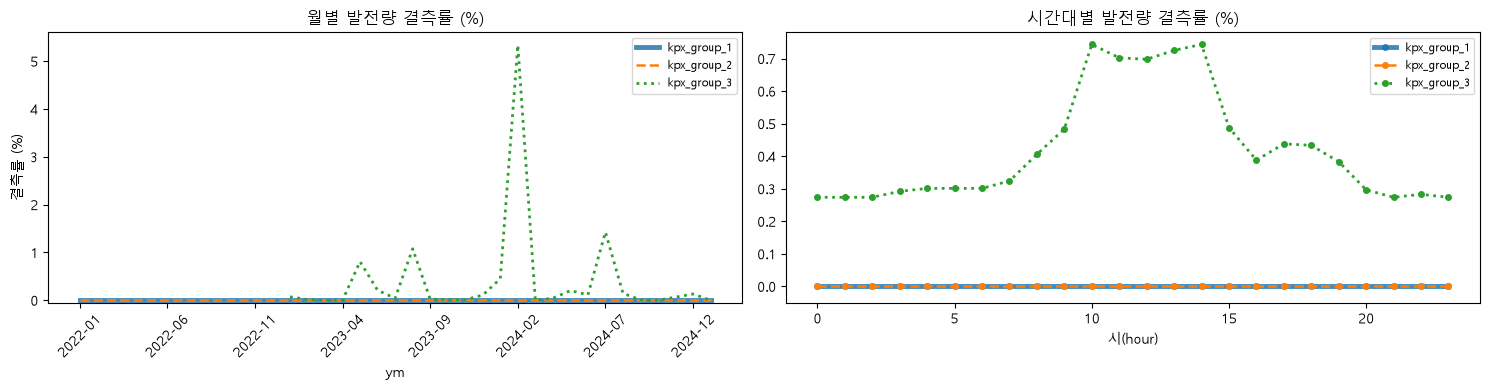

[숫자 확인] 월별 결측률(%) - 그룹별 최소~최대
group  kpx_group_1  kpx_group_2  kpx_group_3
min            0.0          0.0        0.000
max            0.0          0.0        5.335
그룹1·2는 모든 월·모든 시간대에서 결측률이 정확히 0.0이라 두 선이 y=0에 완전히 겹친다


In [18]:
# 그룹3(UNISON)은 2023년부터 시작한다. 이건 결측이 아니라 '애초에 없는 기간'이라
# 0으로 채우거나 앞뒤 값으로 메우면 안 된다
year_counts = scada.groupby([scada["kst_dtm"].dt.year, "group"], observed=True).size().unstack(fill_value=0)
print("연도 x 그룹별 10분 행 수 (그룹3의 2022년이 0인 게 정상)")
print(year_counts)

month_na = (
    scada.assign(ym=scada["kst_dtm"].dt.to_period("M").astype(str))
    .groupby(["ym", "group"], observed=True)["power_raw"]
    .apply(lambda s: s.isna().mean() * 100).unstack()
)
hour_na = (
    scada.groupby([scada["kst_dtm"].dt.hour, "group"], observed=True)["power_raw"]
    .apply(lambda s: s.isna().mean() * 100).unstack()
)

# 주의: 그룹1과 그룹2는 결측률이 둘 다 정확히 0.0이라 선이 y=0에서 완전히 겹친다
# 아무 설정 없이 그리면 나중에 그려지는 그룹2가 그룹1을 덮으므로 선 모양과 굵기를 다르게 준다
LINE_STYLE = {
    "kpx_group_1": {"linestyle": "-", "linewidth": 3.5, "alpha": 0.85},
    # 굵은 실선 (맨 아래에 깔린다)
    "kpx_group_2": {"linestyle": "--", "linewidth": 1.8},
    # 파선 -> 끊긴 틈으로 아래 실선이 비쳐 보인다
    "kpx_group_3": {"linestyle": ":", "linewidth": 2.0},
}

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for col in month_na.columns:
    month_na[col].plot(ax=axes[0], label=col, **LINE_STYLE[col])
axes[0].set_title("월별 발전량 결측률 (%)")
axes[0].set_ylabel("결측률 (%)")
axes[0].set_ylim(bottom=-0.05)
# 0% 선이 축 바닥에 딱 붙어 안 보이는 것을 방지
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=8)

for col in hour_na.columns:
    hour_na[col].plot(ax=axes[1], label=col, marker="o", markersize=4, **LINE_STYLE[col])
axes[1].set_title("시간대별 발전량 결측률 (%)")
axes[1].set_xlabel("시(hour)")
axes[1].set_ylim(bottom=-0.05)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# 그래프에서 겹쳐 보이는 값을 숫자로도 확인한다 (그림만 믿지 말 것)
print("[숫자 확인] 월별 결측률(%) - 그룹별 최소~최대")
print(month_na.agg(["min", "max"]).round(3).to_string())
print("그룹1·2는 모든 월·모든 시간대에서 결측률이 정확히 0.0이라 두 선이 y=0에 완전히 겹친다")

**Step 3 정리**

- VESTAS는 발전량 결측이 **0건**. 대신 Step 4에서 볼 정격 초과 극단값이 숫자로 들어있다
  → 결측률만 보고 "깨끗하다"고 판단하면 안 된다
- UNISON은 터빈별 0.1~1.3% 정도의 결측. 05 문서 기준으로는 "10% 미만"이라 대치·삭제 둘 다 가능한 구간
- 그룹3의 2022년은 결측이 아니라 **없는 기간**이다. 채우지 않는다

## Step 4. 물리한계 기반 이상치 탐지

- 발전량: 제조사 파워 커브 기준
- 기상요소: `04. 전처리 방법론 고민` 참고
- 값을 바꾸지 않고 **플래그(True/False) 컬럼만** 만든다. 지우는 건 Step 5에서 판단한다

특히 구분해야 할 것

- `is_high_wind_zero_power` : 바람은 충분한데 발전 0 → 고장·정비·출력제한 후보. **결측으로 바꾸면 안 된다**
- `is_low_wind_zero_power` : 바람도 없고 발전 0 → 정상 정지

In [19]:
class ScadaQualityChecker:
    """SCADA 물리한계 기반 이상치 탐지를 담당하는 클래스

    Attributes:
        - 값을 바꾸지 않고 플래그만 붙인다
        - 결측·정지·출력제한·센서 오류를 같은 이상치로 뭉개지 않는 것이 목적이다
    """

    def __init__(self, flag_cols: List[str]):
        self.flag_cols = flag_cols
        # ScadaPreprocessor.FLAG_COLS를 받아 순서를 공유한다

    def checkPhysicalLimit(self, scada: pd.DataFrame) -> pd.DataFrame:
        """발전량·풍속의 물리한계를 검사해 플래그 컬럼을 붙이는 메서드

        Logic:
            - 정격 105% 초과 : 비현실적으로 큰 값 (센서 오류)
            - 큰 음수        : 정격 5%보다 큰 음수는 센서·단위 오류 의심
            - 작은 음수      : 대기전력·보조전력일 수 있어 지우지 않는다
            - 컷아웃 이상    : 터빈을 세우는 게 정상이라 발전량 0이 맞다
        """
        scada = scada.copy()
        cap10 = scada["cap_kwh10m"]
        # 터빈별 10분 정격 발전량 (VESTAS 600, UNISON 700 kWh)

        scada["is_power_outlier"] = scada["power_raw"].abs() > cap10 * POWER_CAP_RATIO
        scada["is_power_neg_large"] = scada["power_raw"] < -cap10 * NEG_POWER_RATIO
        scada["is_power_neg_small"] = (scada["power_raw"] < 0) & (~scada["is_power_neg_large"])
        scada["is_ws_out_of_range"] = (scada["ws_raw"] < 0) | (scada["ws_raw"] > WS_PHYS_MAX)
        scada["is_cut_out"] = scada["ws_raw"] >= scada["cut_out_ms"]
        scada["is_low_wind_zero_power"] = (scada["ws_raw"] < CUT_IN_MS) & (scada["power_raw"] <= 0)
        scada["is_high_wind_zero_power"] = (
            (scada["ws_raw"] >= HIGH_WS_MS)
            & (scada["ws_raw"] < scada["cut_out_ms"])
            & (scada["power_raw"] <= 0)
        )
        # 바람은 충분한데 발전이 0. 절대 결측으로 바꾸면 안 되는 값이다
        return scada

    def checkFrozenSensor(self, scada: pd.DataFrame) -> pd.DataFrame:
        """같은 값이 오래 반복되는 센서 고착을 탐지하는 메서드

        Logic:
            - 직전 값과 같고 같은 터빈인 구간에 같은 번호를 매겨 구간 길이를 잰다
            - 0이 반복되는 건 정상 정지라서 제외한다
        """
        scada = scada.copy()
        same_as_prev = (
            scada["power_raw"].eq(scada["power_raw"].shift())
            & scada["turbine"].eq(scada["turbine"].shift())
        )
        run_id = (~same_as_prev).cumsum()
        # 값이 바뀔 때마다 번호를 올려 '같은 값 구간'에 같은 번호를 준다
        run_len = scada.groupby(run_id)["power_raw"].transform("size")
        scada["is_frozen_sensor"] = (
            (run_len >= FROZEN_STEPS) & scada["power_raw"].notna() & (scada["power_raw"] != 0)
        )
        return scada

    def checkTurbineDisagreement(self, scada: pd.DataFrame) -> pd.DataFrame:
        """같은 그룹·같은 시각의 다른 터빈과 크게 어긋나는 값을 탐지하는 메서드

        Logic:
            - 중앙값 계산에서는 정격 초과 극단값을 먼저 빼야 기준이 오염되지 않는다
        """
        scada = scada.copy()
        power_for_median = scada["power_raw"].mask(scada["is_power_outlier"])
        group_median = power_for_median.groupby(
            [scada["kst_dtm"], scada["group"]], observed=True
        ).transform("median")
        scada["is_turbine_disagreement"] = (
            (power_for_median - group_median).abs() > scada["cap_kwh10m"] * DISAGREE_RATIO
        )
        return scada

    def summarize(self, scada: pd.DataFrame) -> pd.DataFrame:
        """플래그별 검출 건수와 비율을 표로 요약하는 메서드"""
        return pd.DataFrame({
            "건수": scada[self.flag_cols].sum(),
            "비율(%)": (scada[self.flag_cols].mean() * 100).round(3),
        })

In [20]:
quality_checker = ScadaQualityChecker(flag_cols=ScadaPreprocessor.FLAG_COLS)

scada = quality_checker.checkPhysicalLimit(scada)
scada = quality_checker.checkFrozenSensor(scada)
scada = quality_checker.checkTurbineDisagreement(scada)

flag_summary = quality_checker.summarize(scada)
print("플래그별 검출 건수 (10분 단위 기준, 전체 %d행)" % len(scada))
flag_summary

플래그별 검출 건수 (10분 단위 기준, 전체 2420148행)


,건수,비율(%)
is_power_outlier,1350,0.056
is_power_neg_large,434,0.018
is_power_neg_small,316787,13.090
is_frozen_sensor,7447,0.308
is_high_wind_zero_power,95273,3.937
is_low_wind_zero_power,391611,16.181
is_cut_out,999,0.041
is_ws_out_of_range,0,0.000
is_turbine_disagreement,45382,1.875


In [21]:
# 터빈별로 어떤 플래그가 몇 개인지도 확인한다
by_turbine = scada.groupby("turbine", observed=True)[ScadaPreprocessor.FLAG_COLS].sum()
print("터빈별 플래그 건수")
by_turbine

터빈별 플래그 건수


,is_power_outlier,is_power_neg_large,is_power_neg_small,is_frozen_sensor,is_high_wind_zero_power,is_low_wind_zero_power,is_cut_out,is_ws_out_of_range,is_turbine_disagreement
turbine,,,,,,,,,
unison_wtg01,19,0,0,228,6723,26095,1,0,4516
unison_wtg02,10,0,0,412,3617,31538,33,0,2904
unison_wtg03,60,0,0,1502,3643,27317,40,0,1198
unison_wtg04,99,0,0,1265,4647,27275,96,0,1644
unison_wtg05,294,0,0,3067,4458,25170,76,0,2013
vestas_wtg01,74,37,24747,182,7603,20604,1,0,3750
vestas_wtg02,70,35,23716,22,4104,20923,40,0,2066
vestas_wtg03,88,44,21462,0,4238,19479,67,0,1026
vestas_wtg04,44,22,26701,158,8128,20272,15,0,2314


In [22]:
# LDAPS 물리 일관성 검사. 통과 X여도 값을 지우지 않고 플래그만 남긴다
ldaps = contract_checker.checkPhysicalConsistency(ldaps)

ldaps_qc_report = contract_checker.summarize()
ldaps_qc_report = ldaps_qc_report[ldaps_qc_report["대상"] == "ldaps"].tail(6)
# 방금 추가한 물리 일관성 검사 6건만 따로 본다
print("LDAPS 품질검사")
ldaps_qc_report

LDAPS 품질검사


,대상,검사항목,통과,내용
13,ldaps,NaN·Inf 없음,O,NaN 0개 / Inf 0개
14,ldaps,기온 >= 이슬점,X,위반 6398건
15,ldaps,상대습도 0~100%,X,"100% 초과 16649건, 최대 110.4%"
16,ldaps,기압 범위,O,87463 ~ 93083 Pa
17,ldaps,비습 범위,O,0.00024 ~ 0.02125 kg/kg
18,ldaps,육지/해양 마스크,O,lsm 값 종류 = [np.float64(1.0)] (전부 육지)


**Step 4 정리**

- SCADA 발전량 정격 105% 초과는 VESTAS에서 주로 나온다 → Step 5에서 NaN 처리
- `is_high_wind_zero_power`(바람은 충분한데 발전 0)는 고장·정비·출력제한 후보. **결측으로 바꾸지 않는다**
- `is_low_wind_zero_power`(바람도 없고 발전 0)는 정상 정지. 이것도 그대로 둔다
- 작은 음수는 대기전력일 수 있어 지우지 않고 플래그만 남긴다
- LDAPS 물리 검사에서 **두 건이 통과 X**로 나오는데 둘 다 수치예보 모델 산출물의 특성이라 값은 유지한다
  - 상대습도 100% 초과 16,649건 (최대 110.4%)
  - 기온 < 이슬점 6,398건 (전체의 1.5%). 과포화 상태를 모델이 그대로 내보낸 것으로 보인다
  - 관측자료였다면 센서 고장을 의심할 값이지만, 모델 결과라 지우지 않고 `is_rh_over_100` /
    `is_temp_below_dew` 플래그로만 남긴다. 습도 파생변수를 쓸 때 이 플래그를 같이 보면 된다

## Step 5. 이상치 NaN 변환 및 QC 비트 코드

원본 컬럼은 그대로 두고 정제값을 **별도 컬럼**으로 만든다.
`power_raw`(원본) / `power_clean`(정제) / `power_qc_flag`(비트 코드) 세 컬럼 구조라
원본을 지우지 않았으니 언제든 되돌려 확인할 수 있다.

In [23]:
class ScadaCleaner:
    """플래그를 근거로 이상치를 NaN으로 바꾸고 QC 코드를 남기는 클래스

    Attributes:
        - NaN으로 바꾸는 건 정격 초과 · 큰 음수 · 센서 고착 세 가지뿐이다
        - 발전량 0, 작은 음수, 고풍속 무발전, 컷아웃은 값을 유지하고 플래그만 남긴다
    """

    def __init__(self, flag_cols: List[str], drop_flags: List[str]):
        self.flag_cols = flag_cols
        self.drop_flags = drop_flags
        self.qc_bits = {name: 1 << i for i, name in enumerate(flag_cols)}
        # 플래그마다 2의 거듭제곱 값을 하나씩 배정해 정수 하나에 상태를 담는다

    def transformOutlierToNaN(self, scada: pd.DataFrame) -> pd.DataFrame:
        """못 믿을 값만 NaN으로 바꾸는 메서드

        Logic:
            - wd는 UNISON이 -180~180 표기라서 % 360으로 0~360에 맞춘다
              (VESTAS는 원래 0~360이라 값이 변하지 않는다)
        """
        scada = scada.copy()
        scada["power_clean"] = scada["power_raw"].mask(scada[self.drop_flags].any(axis=1))
        scada["ws_clean"] = scada["ws_raw"].mask(scada["is_ws_out_of_range"])
        # 물리한계 밖 풍속만 NaN으로
        scada["wd_clean"] = scada["wd_raw"] % 360
        return scada

    def computeQcCode(self, scada: pd.DataFrame) -> pd.DataFrame:
        """어떤 플래그가 걸렸는지를 정수 하나에 담는 메서드

        Logic:
            - 플래그가 9개라 컬럼 9개를 계속 들고 다니는 대신 비트 코드로 압축한다
            - 나중에 (power_qc_flag & QC_BITS["is_cut_out"]) > 0 처럼 특정 상태만 골라볼 수 있다
        """
        scada = scada.copy()
        qc_code = np.zeros(len(scada), dtype=np.int32)
        for name, bit in self.qc_bits.items():
            qc_code += scada[name].to_numpy() * bit
            # True인 행에만 그 비트를 더한다
        scada["power_qc_flag"] = qc_code
        return scada

    def computeHourCoverage(self, scada: pd.DataFrame) -> pd.DataFrame:
        """시간당 유효 샘플 수와 부분/전체 결측 여부를 계산하는 메서드"""
        scada = scada.copy()
        n_valid = scada.groupby(["turbine", "hour_end"], observed=True)["power_clean"].transform("count")
        scada["n_valid_in_hour"] = n_valid
        scada["is_partial_missing"] = (n_valid > 0) & (n_valid < MIN_SAMPLES_PER_HOUR)
        # 10분값이 1~5개만 남은 시간
        scada["is_full_missing_hour"] = n_valid == 0
        # 그 시간이 통째로 비어있는 경우
        return scada

In [24]:
cleaner = ScadaCleaner(flag_cols=ScadaPreprocessor.FLAG_COLS, drop_flags=ScadaPreprocessor.DROP_FLAGS)

scada = cleaner.transformOutlierToNaN(scada)
scada = cleaner.computeQcCode(scada)
scada = cleaner.computeHourCoverage(scada)

print("정제 전후 비교")
print(f"  power_raw   결측: {scada['power_raw'].isna().sum():,}건")
print(f"  power_clean 결측: {scada['power_clean'].isna().sum():,}건 (플래그로 NaN 처리한 만큼 늘어남)")
print(f"  발전량 0인 행: {(scada['power_clean'] == 0).sum():,}건 <- NaN으로 바꾸지 않고 그대로 둔다")
print(f"  부분 결측 시간에 속한 행: {int(scada['is_partial_missing'].sum()):,}건")
print(f"  통째로 빈 시간에 속한 행: {int(scada['is_full_missing_hour'].sum()):,}건")
print()
print("QC 비트 배정:", cleaner.qc_bits)

정제 전후 비교
  power_raw   결측: 2,214건
  power_clean 결측: 11,011건 (플래그로 NaN 처리한 만큼 늘어남)
  발전량 0인 행: 322,148건 <- NaN으로 바꾸지 않고 그대로 둔다
  부분 결측 시간에 속한 행: 8,916건
  통째로 빈 시간에 속한 행: 8,166건

QC 비트 배정: {'is_power_outlier': 1, 'is_power_neg_large': 2, 'is_power_neg_small': 4, 'is_frozen_sensor': 8, 'is_high_wind_zero_power': 16, 'is_low_wind_zero_power': 32, 'is_cut_out': 64, 'is_ws_out_of_range': 128, 'is_turbine_disagreement': 256}


## Step 6. 결측 패턴·연속 길이 분석

의심: 결측값에도 패턴이 있다면 계절 요인이나 주기적 정비 소요로 반복되지 않을까?

짧은 구멍(통신 순간 끊김)은 메울 수 있지만 긴 구멍(정비·고장)은 손대면 안 되므로,
먼저 **연속 결측 길이**부터 잰다.

In [25]:
class MissingPatternAnalyzer:
    """결측의 연속 길이와 발생 패턴 분석을 담당하는 클래스

    Attributes:
        - 짧은 구멍은 통신 순간 끊김, 긴 구멍은 정비·고장으로 보고 처리 방법을 다르게 간다
    """

    def computeRunLength(self, df: pd.DataFrame, col: str, key: str = "turbine") -> pd.Series:
        """연속 결측 구간의 길이를 각 행에 붙이는 메서드

        Args:
            - col : 결측을 볼 컬럼
            - key : 구간이 넘어가면 안 되는 경계 컬럼 (터빈이 바뀌면 구간도 끊긴다)

        Logic:
            - 상태(결측/정상)가 바뀔 때마다 번호를 올려 같은 상태 구간에 같은 번호를 준다
            - 값이 있는 행은 0으로 채워 결측 구간만 길이가 남게 한다
        """
        na_mask = df[col].isna()
        same_run = na_mask.eq(na_mask.shift()) & df[key].eq(df[key].shift())
        run_id = (~same_run).cumsum()
        run_len = df.groupby(run_id)[col].transform("size")
        return run_len.where(na_mask, 0).astype("int32")

    def summarizeGapRun(self, df: pd.DataFrame, col: str, key: str = "turbine") -> pd.DataFrame:
        """결측 구간을 구간당 한 줄로 뽑아 길이 분포를 보는 메서드"""
        na_mask = df[col].isna()
        same_run = na_mask.eq(na_mask.shift()) & df[key].eq(df[key].shift())
        run_id = (~same_run).cumsum()
        run_len = df.groupby(run_id)[col].transform("size")

        runs = pd.DataFrame({"run_id": run_id, "is_na": na_mask, "len": run_len})
        return runs[runs["is_na"]].drop_duplicates("run_id")

    def plotMissingPattern(self, scada: pd.DataFrame, col: str = "power_clean") -> None:
        """월별·요일별·시간대별 결측률을 나란히 그리는 메서드

        Logic:
            - 정비는 보통 낮 시간에 하므로 낮에 결측이 몰려 있으면 정비 흔적을 의심할 수 있다
        """
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        by_month = scada.groupby(scada["kst_dtm"].dt.month, observed=True)[col].apply(lambda s: s.isna().mean() * 100)
        by_month.plot(kind="bar", ax=axes[0], color="tab:blue")
        axes[0].set_title("월별 결측률 (%)")
        axes[0].set_xlabel("월")

        by_dow = scada.groupby(scada["kst_dtm"].dt.dayofweek, observed=True)[col].apply(lambda s: s.isna().mean() * 100)
        by_dow.plot(kind="bar", ax=axes[1], color="tab:orange")
        axes[1].set_title("요일별 결측률 (%) 0=월요일")
        axes[1].set_xlabel("요일")

        by_hour = scada.groupby(scada["kst_dtm"].dt.hour, observed=True)[col].apply(lambda s: s.isna().mean() * 100)
        by_hour.plot(kind="bar", ax=axes[2], color="tab:green")
        axes[2].set_title("시간대별 결측률 (%)")
        axes[2].set_xlabel("시(hour)")

        plt.tight_layout()
        plt.show()

In [26]:
missing_analyzer = MissingPatternAnalyzer()

scada["na_run_len"] = missing_analyzer.computeRunLength(scada, "power_clean")
gap_runs = missing_analyzer.summarizeGapRun(scada, "power_clean")

print(f"결측 구간 개수: {len(gap_runs):,}개")
print()
print("연속 결측 길이 분포 (10분 단위. 1=10분, 6=1시간, 144=1일)")
print(gap_runs["len"].describe().round(1).to_string())
print()
print(f"20분 이하 짧은 구멍: {int((gap_runs['len'] <= MAX_INTERP_STEPS).sum()):,}개 구간 -> Step 7에서 보간")
print(f"그보다 긴 구멍: {int((gap_runs['len'] > MAX_INTERP_STEPS).sum()):,}개 구간 -> 보간하지 않고 플래그 유지")

결측 구간 개수: 1,295개

연속 결측 길이 분포 (10분 단위. 1=10분, 6=1시간, 144=1일)
count    1295.0
mean        8.5
std        22.1
min         1.0
25%         1.0
50%         1.0
75%         3.0
max       430.0

20분 이하 짧은 구멍: 962개 구간 -> Step 7에서 보간
그보다 긴 구멍: 333개 구간 -> 보간하지 않고 플래그 유지


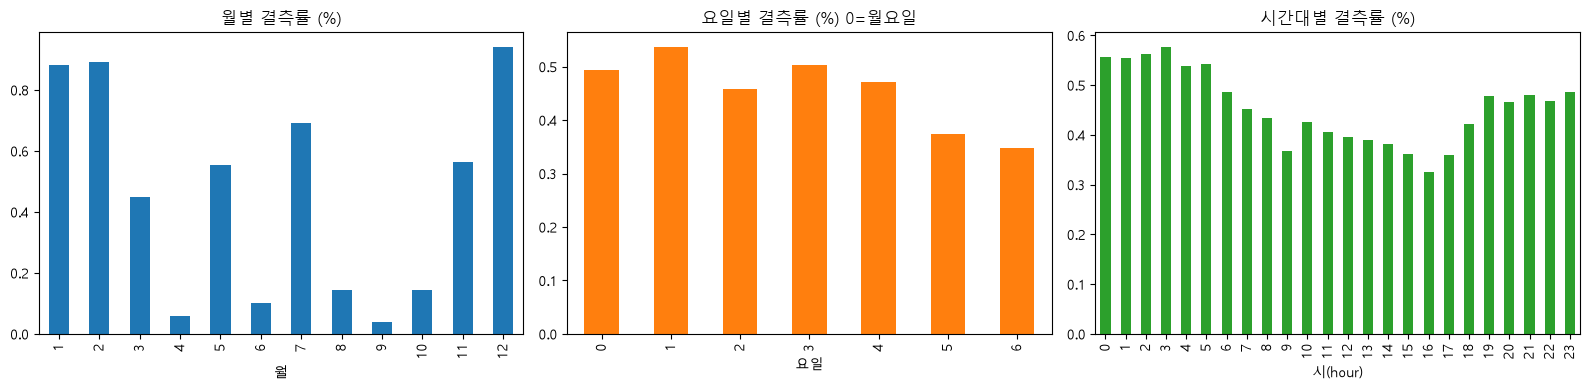

주간(9~17시) 결측률 0.38%  vs  그 외 시간 0.50%


In [27]:
missing_analyzer.plotMissingPattern(scada)

day_na = scada.loc[scada["kst_dtm"].dt.hour.between(9, 17), "power_clean"].isna().mean() * 100
night_na = scada.loc[~scada["kst_dtm"].dt.hour.between(9, 17), "power_clean"].isna().mean() * 100
print(f"주간(9~17시) 결측률 {day_na:.2f}%  vs  그 외 시간 {night_na:.2f}%")
# 주간 결측률이 뚜렷하게 높으면 정비 흔적을 의심할 수 있다

## Step 7. 단기 결측 보간

- 20분(10분값 2칸) 이하 짧은 구멍만 선형보간하고 그보다 긴 구멍은 **일부러 비워둔다**
- 긴 구멍을 억지로 채우면 통신 장애나 정비 정지를 '실제 저발전'으로 학습하게 된다 (06 문서 2.2)
- 보간한 자리는 표시로 남겨 "보간값을 빼고 학습" 실험도 가능하게 한다
- 풍향은 각도라서 선형보간하면 0도와 359도 사이에서 엉뚱한 값이 나온다.
  그래서 여기서 안 건드리고 Step 8에서 U·V 성분으로 바꾼 다음에 보간한다

In [28]:
class GapInterpolator:
    """짧은 결측만 선형보간하고 긴 결측은 남겨두는 것을 담당하는 클래스

    Attributes:
        - max_steps : 이 칸수 이하의 연속 결측만 보간한다 (기본 2칸 = 20분)
    """

    def __init__(self, max_steps: int = MAX_INTERP_STEPS):
        self.max_steps = max_steps

    def interpolateShortGap(
        self,
        df: pd.DataFrame,
        col: str,
        key: str = "turbine",
    ) -> Tuple[pd.Series, pd.Series]:
        """연속 결측이 max_steps 이하인 짧은 구멍만 선형보간하는 메서드

        Args:
            - col : 보간할 컬럼
            - key : 터빈 경계를 넘어 보간하지 않도록 묶는 컬럼

        Logic:
            - limit_area="inside"라 양쪽에 값이 있을 때만 채운다 (표 끝의 결측은 안 건드린다)
            - 반환값은 (채운 결과, 실제로 채운 자리 표시) 두 개다
        """
        na_mask = df[col].isna()
        same_run = na_mask.eq(na_mask.shift()) & df[key].eq(df[key].shift())
        run_len = df.groupby((~same_run).cumsum())[col].transform("size")
        short_gap = na_mask & (run_len <= self.max_steps)
        # 짧은 구멍만 True

        interpolated = df.groupby(key, observed=True)[col].transform(
            lambda s: s.interpolate(method="linear", limit_area="inside")
        )
        filled = df[col].where(~short_gap, interpolated)
        # 짧은 구멍 자리에만 보간값을 넣는다
        return filled, (short_gap & filled.notna())

In [29]:
interpolator = GapInterpolator()

scada["power_filled"], scada["is_power_interpolated"] = interpolator.interpolateShortGap(scada, "power_clean")
scada["ws_filled"], scada["is_ws_interpolated"] = interpolator.interpolateShortGap(scada, "ws_clean")

print("보간 결과")
print(f"  power: 결측 {scada['power_clean'].isna().sum():,}건 -> {scada['power_filled'].isna().sum():,}건 "
      f"(보간 {int(scada['is_power_interpolated'].sum()):,}건)")
print(f"  ws   : 결측 {scada['ws_clean'].isna().sum():,}건 -> {scada['ws_filled'].isna().sum():,}건 "
      f"(보간 {int(scada['is_ws_interpolated'].sum()):,}건)")
print()
print("남은 결측은 20분보다 긴 구멍이라 일부러 채우지 않았다")

보간 결과
  power: 결측 11,011건 -> 9,846건 (보간 1,165건)
  ws   : 결측 5,096건 -> 4,849건 (보간 247건)

남은 결측은 20분보다 긴 구멍이라 일부러 채우지 않았다


## Step 8. SCADA·LDAPS 파생변수 생성

발전량 산출 공식에 들어가는 풍향·풍속·공기밀도·수풍면적을 만든다 (04 문서 참고).

$$P = \frac{1}{2} \rho A V^3 C_p$$

**순서 문제가 중요하다.** 공기밀도나 풍력에너지 밀도처럼 **비선형** 계산은 격자별로 먼저 하고
나중에 평균해야 한다. 평균 기온·평균 기압으로 밀도를 한 번 계산하면 값이 미묘하게 틀린다.

In [30]:
# LDAPS 격자별 파생변수 생성 + 급변 플래그
ldaps = ldaps_preprocessor.calculateGridFeature(ldaps)
ldaps = ldaps_preprocessor.checkJump(ldaps)

print("공기밀도 확인 (표준 대기 1.225 kg/m³ 근처여야 정상)")
print("태백 산지 900m 고도라 조금 낮게 나오는 것이 맞다")
print(ldaps[["sp", "t2m", "q2m", "e_pa", "air_density", "ws10", "wind_power_density"]]
      .describe().T[["min", "mean", "max"]].round(4))

in_range = ldaps["air_density"].between(0.9, 1.4).mean() * 100
print(f"\n공기밀도가 0.9~1.4 kg/m³ 안에 있는 비율: {in_range:.2f}%")
print(f"시간 급변 플래그: {int(ldaps['is_ws_time_jump'].sum()):,}건 ({ldaps['is_ws_time_jump'].mean() * 100:.3f}%)")
print(f"공간 급변 플래그: {int(ldaps['is_ws_space_jump'].sum()):,}건 ({ldaps['is_ws_space_jump'].mean() * 100:.3f}%)")
print("\n격자 간 풍속 편차(ws10_spatial_range) 분포 - 16격자를 통째로 평균하면 이 정보가 사라진다")
print(ldaps.groupby("forecast_kst_dtm")["ws10_spatial_range"].first().describe().round(2).to_string())

공기밀도 확인 (표준 대기 1.225 kg/m³ 근처여야 정상)
태백 산지 900m 고도라 조금 낮게 나오는 것이 맞다
                           min        mean         max
sp                  87462.8100  90673.4919  93083.1300
t2m                   249.6983    281.1693    302.9151
q2m                     0.0002      0.0070      0.0212
e_pa                   35.0660   1015.4268   3031.5979
air_density             1.0224      1.1205      1.2672
ws10                    0.0056      4.8362     18.4123
wind_power_density      0.0000    128.6540   3601.8207

공기밀도가 0.9~1.4 kg/m³ 안에 있는 비율: 100.00%
시간 급변 플래그: 0건 (0.000%)
공간 급변 플래그: 16건 (0.004%)

격자 간 풍속 편차(ws10_spatial_range) 분포 - 16격자를 통째로 평균하면 이 정보가 사라진다
count    26304.00
mean         2.46
std          1.31
min          0.15
25%          1.47
50%          2.21
75%          3.18
max         10.62


In [31]:
# [테스트 코드] Step 8. 풍향 변환 검증
# 04 문서의 검증표를 그대로 재현한다. 부호 실수는 여기서 안 잡으면 끝까지 못 잡는다

check_uv = pd.DataFrame({
    "u": [0.0, 0.0, 1.0, -1.0],
    "v": [1.0, -1.0, 0.0, 0.0],
    "기대 풍향": [180.0, 0.0, 270.0, 90.0],
    "의미": ["남풍(남쪽에서 옴)", "북풍(북쪽에서 옴)", "서풍(서쪽에서 옴)", "동풍(동쪽에서 옴)"],
})
check_uv["계산 풍향"] = ldaps_preprocessor.computeWindDirection(check_uv["u"], check_uv["v"])
check_uv["일치"] = np.isclose(check_uv["계산 풍향"], check_uv["기대 풍향"])

print("풍향 변환 검증 ('일치'가 전부 True여야 한다)")
check_uv

풍향 변환 검증 ('일치'가 전부 True여야 한다)


,u,v,기대 풍향,의미,계산 풍향,일치
0,0.0,1.0,180.0,남풍(남쪽에서 옴),180.0,True
1,0.0,-1.0,0.0,북풍(북쪽에서 옴),0.0,True
2,1.0,0.0,270.0,서풍(서쪽에서 옴),270.0,True
3,-1.0,0.0,90.0,동풍(동쪽에서 옴),90.0,True


### Step 8-1. SCADA 풍향도 각도 대신 U·V로

풍향을 각도 상태로 평균하면 0도와 359도의 평균이 180도가 되는 사고가 난다.
그래서 터빈별로 먼저 U·V 성분으로 바꿔두고 평균은 성분 단위로 한다.

기상학적 풍향(바람이 불어오는 방향)에서 성분으로 갈 때는 부호를 뒤집는다.

- `u = -ws x sin(풍향)`
- `v = -ws x cos(풍향)`

**수풍면적과 이론 출력**도 여기서 계산한다. `A`는 터빈 모델마다 고정값이라 스펙 시트 값을 쓴다.

- V126: 12,469 m² (로터 126m)
- U136: 14,470 m² (로터 136m) — 04 문서의 추정치 14,527 대신 실제 스펙값

In [32]:
class ScadaFeatureEngineer(WindVectorTransformer):
    """SCADA 세로 표의 파생변수 생성을 담당하는 클래스

    Attributes:
        - 풍향은 U·V로 바꾼 다음에 보간해야 0도/359도 경계에서 엉뚱한 값이 안 나온다
    """

    def __init__(self, interpolator: GapInterpolator):
        super().__init__()
        self.interpolator = interpolator
        # U·V로 바꾼 뒤 짧은 구멍을 메우기 위해 보간기를 들고 있는다

    def transformWindToUV(self, scada: pd.DataFrame) -> pd.DataFrame:
        """SCADA 풍속·풍향을 U·V 성분으로 바꾸고 짧은 구멍을 보간하는 메서드

        Logic:
            - 각도를 직접 보간하면 0도/359도 경계에서 엉뚱한 값이 나오므로 성분으로 바꾼 뒤 보간한다
            - 풍속이 거의 0일 때 풍향은 의미가 약해서 방향 통계에서 뺄 수 있게 dir_valid를 남긴다
        """
        scada = scada.copy()
        u, v = self.computeUVComponent(scada["ws_filled"], scada["wd_clean"])
        scada["u_scada"] = u.astype("float32")
        scada["v_scada"] = v.astype("float32")

        scada["u_scada"], scada["is_u_interpolated"] = self.interpolator.interpolateShortGap(scada, "u_scada")
        scada["v_scada"], _ = self.interpolator.interpolateShortGap(scada, "v_scada")

        scada["dir_valid"] = scada["ws_filled"] >= LOW_WS_MASK
        return scada

    def checkUVRoundTrip(self, scada: pd.DataFrame) -> float:
        """U·V에서 풍향을 되돌려 원래 각도가 복원되는지 확인하는 메서드

        Logic:
            - 변환 실수를 잡기 위한 왕복 검증이다. 평균 차이가 0에 가까워야 정상이다
        """
        restored = self.computeWindDirection(scada["u_scada"], scada["v_scada"])
        usable = scada["dir_valid"] & scada["wd_clean"].notna() & scada["u_scada"].notna()
        diff = self.computeAngleDifference(restored, scada["wd_clean"]).abs()
        return float(diff[usable].mean())

    def calculateTheoreticalPower(self, scada: pd.DataFrame) -> pd.DataFrame:
        """표준 밀도 기준 이론 출력과 순간 출력(kW)을 계산하는 메서드

        Logic:
            - P = 0.5 x rho x A x V^3 (W) 이므로 1000으로 나눠 kW로 바꾼다
            - 실제 밀도는 LDAPS에서 오므로 여기서는 표준 밀도(1.225)로만 계산한다
            - 10분 에너지(kWh)에 6을 곱해 순간 출력(kW)으로 환산한다
        """
        scada = scada.copy()
        scada["p_theory_std_kw"] = (
            0.5 * RHO_STD * scada["swept_area_m2"] * scada["ws_filled"] ** 3 / 1000
        ).astype("float32")
        scada["power_kw"] = (scada["power_filled"] * MIN_SAMPLES_PER_HOUR).astype("float32")
        return scada

    def evaluatePowerCoefficient(self, scada: pd.DataFrame, ws_upper: float = 10.0) -> pd.DataFrame:
        """컷인~정격 사이 구간에서 Cp(터빈 효율)를 추정하는 메서드

        Args:
            - ws_upper : 정격 포화가 시작되기 전까지의 풍속 상한

        Logic:
            - Cp = 실제 출력 / 이론 출력
            - 베츠 한계(0.593)를 넘는 값이 섞여 나오는데 계산이 틀린 게 아니다.
              SCADA 풍속계가 나셀(로터 뒤쪽)에 있어 후류 영향으로 풍속을 낮게 읽고,
              10분 평균 풍속을 세제곱하면 원래보다 작아지는 방향으로 편향되기 때문이다(젠센 부등식)
            - 그래서 발전량÷풍속³을 터빈 효율로 바로 해석하면 안 된다 (06 문서 2.11)
        """
        band = (
            scada["ws_filled"].between(CUT_IN_MS, ws_upper)
            & (scada["power_kw"] > 0)
            & scada["p_theory_std_kw"].notna()
        )
        cp_est = scada.loc[band, "power_kw"] / scada.loc[band, "p_theory_std_kw"]
        summary = cp_est.groupby(scada.loc[band, "model"], observed=True).describe()[["count", "mean", "50%", "max"]]
        summary["베츠한계 초과(%)"] = (
            (cp_est > BETZ_LIMIT).groupby(scada.loc[band, "model"], observed=True).mean() * 100
        )
        return summary.round(3)

In [33]:
scada_engineer = ScadaFeatureEngineer(interpolator)

scada = scada_engineer.transformWindToUV(scada)
scada = scada_engineer.calculateTheoreticalPower(scada)

print("SCADA U·V 성분 변환 결과")
print(scada[["ws_filled", "wd_clean", "u_scada", "v_scada"]].describe().T[["min", "mean", "max"]].round(3))
print(f"\n방향 통계에서 제외할 저풍속 행(풍속 < {LOW_WS_MASK} m/s): {int((~scada['dir_valid']).sum()):,}건")
print(f"복원한 풍향과 원래 풍향의 평균 차이: {scada_engineer.checkUVRoundTrip(scada):.6f}도 (0에 가까워야 정상)")

SCADA U·V 성분 변환 결과
              min     mean      max
ws_filled   0.000    6.743   32.050
wd_clean    0.000  206.341  359.891
u_scada   -20.297    3.959   30.332
v_scada   -18.108    0.482   26.024

방향 통계에서 제외할 저풍속 행(풍속 < 1.0 m/s): 50,215건
복원한 풍향과 원래 풍향의 평균 차이: 0.000006도 (0에 가까워야 정상)


In [34]:
print("모델별 수풍면적:", SWEPT_AREA_M2)
print()
print("컷인~10m/s 구간에서 추정한 Cp")
print(scada_engineer.evaluatePowerCoefficient(scada))
print()
print("중앙값은 그럴듯한데 최댓값이 베츠 한계(0.593)를 훌쩍 넘는다.")
print("계산이 틀린 게 아니라 나셀 풍속계가 후류 영향으로 풍속을 낮게 읽는 탓이다.")
print("-> 발전량÷풍속³을 터빈 효율로 바로 해석하면 안 되고 파워커브 잔차로 봐야 한다")

모델별 수풍면적: {'V126': 12469.0, 'U136': 14470.0}

컷인~10m/s 구간에서 추정한 Cp
           count   mean    50%    max  베츠한계 초과(%)
model                                            
U136    232266.0  0.576  0.495  7.816      33.936
V126   1070134.0  0.317  0.349  1.171       0.139

중앙값은 그럴듯한데 최댓값이 베츠 한계(0.593)를 훌쩍 넘는다.
계산이 틀린 게 아니라 나셀 풍속계가 후류 영향으로 풍속을 낮게 읽는 탓이다.
-> 발전량÷풍속³을 터빈 효율로 바로 해석하면 안 되고 파워커브 잔차로 봐야 한다


**Step 8 정리**

- LDAPS 파생변수는 **격자별로 먼저** 계산했다 (공기밀도·풍력에너지 밀도가 비선형이라 평균 순서가 중요)
- 풍향 변환은 04 문서의 검증표(남풍 180 / 북풍 0 / 서풍 270 / 동풍 90)로 확인 완료
- SCADA 풍향은 U·V로 바꾼 뒤 보간했고 되돌려서 원래 각도가 복원되는 것까지 확인
- 50m 바람은 max·min을 직접 합치지 않고 **변동폭**으로만 사용
- Cp 추정 결과 중앙값은 그럴듯한데 **베츠 한계를 넘는 값이 섞여 있다** → 나셀 풍속계 후류 영향

## Step 9. 10분 SCADA를 시간 단위로 집계

처음엔 "단순 총합 하면 될 것 같다"고 적어뒀는데 06 문서 2.2를 보고 생각을 바꿨다.
총합 자체는 맞다. 문제는 **결측이 있을 때**다.

```python
# 이렇게 하면 안 된다
df.groupby("hour_end")[power_cols].sum(min_count=1).sum(axis=1)
```

- 어떤 터빈에 10분 자료가 한두 개만 있어도 그걸 정상적인 1시간 발전량으로 써버린다
- 모든 값이 결측인 터빈은 첫 합계에서 NaN이 되지만, 두 번째 `sum(axis=1)`에서 그 NaN이 **무시**된다
  → 터빈이 전부 죽어 있어도 그룹 발전량이 계산된다

즉 센서 고장이나 통신 장애를 실제 저발전으로 학습하게 된다. 그래서 `min_count`를 **두 단계 모두에** 명시한다.

In [35]:
class ScadaAggregator(WindVectorTransformer):
    """10분 SCADA를 터빈 시간별 -> KPX 그룹 시간별로 집계하는 클래스

    Attributes:
        - 1단계 : 터빈 x 시간 (10분값 6개 -> 1시간)
        - 2단계 : 터빈 -> 그룹 (터빈 수를 충족할 때만 합산)
        - 두 단계 모두 min_count를 명시해야 결측이 발전량 0으로 둔갑하지 않는다
    """

    def __init__(self, turbine_group: Dict[str, str], turbine_cap_kwh10m: Dict[str, float]):
        super().__init__()
        self.turbine_group = turbine_group
        self.turbine_cap_kwh10m = turbine_cap_kwh10m

    def transformToTurbineHourly(self, scada: pd.DataFrame) -> pd.DataFrame:
        """터빈 x 시간 단위로 집계하는 메서드

        Logic:
            - power_sum_strict  : 10분값 6개가 다 있을 때만 인정
            - power_sum_relaxed : 5/6만 있어도 인정하되 6/n으로 보정 (안 하면 과소평가된다)
            - 두 버전을 같이 만들어 나중에 검증 데이터에서 어느 쪽이 나은지 비교한다
        """
        grouped = scada.groupby(["turbine", "hour_end"], observed=True)
        agg = grouped.agg(
            n_valid=("power_filled", "count"),
            # 그 시간에 살아있는 10분값 개수 (0~6)
            power_sum_all=("power_filled", "sum"),
            # 일단 합계. min_count는 아래에서 직접 적용한다
            ws_mean=("ws_filled", "mean"),
            ws_std=("ws_filled", "std"),
            # 10분 사이 풍속 변동
            ws_max=("ws_filled", "max"),
            u_mean=("u_scada", "mean"),
            v_mean=("v_scada", "mean"),
            is_high_wind_zero=("is_high_wind_zero_power", "any"),
            is_cut_out_hour=("is_cut_out", "any"),
            is_outlier_hour=("is_power_outlier", "any"),
            is_interp_hour=("is_power_interpolated", "any"),
        ).reset_index()

        ws_quantile = grouped["ws_filled"].quantile([0.25, 0.75]).unstack()
        ws_quantile.columns = ["ws_q25", "ws_q75"]
        agg = agg.merge(ws_quantile.reset_index(), on=["turbine", "hour_end"], how="left")

        agg["power_sum_strict"] = agg["power_sum_all"].where(agg["n_valid"] >= MIN_SAMPLES_PER_HOUR)
        agg["power_sum_relaxed"] = (
            agg["power_sum_all"] * MIN_SAMPLES_PER_HOUR / agg["n_valid"]
        ).where(agg["n_valid"] >= MIN_SAMPLES_RELAXED)
        # 5개만 더하면 과소평가되므로 6/n으로 보정한다

        agg["group"] = agg["turbine"].map(self.turbine_group)
        agg["cap_kwh10m"] = agg["turbine"].map(self.turbine_cap_kwh10m)
        return agg

    def transformToGroupHourly(self, agg_turbine: pd.DataFrame) -> pd.DataFrame:
        """터빈 시간별 표를 KPX 그룹 시간별 표로 집계하는 메서드

        Logic:
            - 그룹 합계도 min_count=len(members)를 줘서 한 터빈이라도 비면 NaN이 되게 한다
            - 풍속은 scalar 평균과 vector 평균을 둘 다 보존한다
              (둘의 비율이 풍향이 얼마나 일정했는지를 알려준다)
            - coverage_ratio / avail_cap_ratio를 남겨 통신 장애로 낮게 나온 시간을 나중에 걸러낼 수 있게 한다
        """
        wide = {
            key: agg_turbine.pivot(index="hour_end", columns="turbine", values=key)
            for key in ["power_sum_strict", "power_sum_relaxed", "n_valid", "ws_mean", "u_mean", "v_mean"]
        }

        group_parts = []
        for group in GROUPS:
            members = [t for t in wide["power_sum_strict"].columns if self.turbine_group[t] == group]
            caps = np.array([self.turbine_cap_kwh10m[t] for t in members])
            cap_total = caps.sum() * MIN_SAMPLES_PER_HOUR
            # 그룹 1시간 설비용량(kWh). GROUP_CAP_KWH와 같아야 한다

            power_strict = wide["power_sum_strict"][members].sum(axis=1, min_count=len(members))
            power_relaxed = wide["power_sum_relaxed"][members].sum(axis=1, min_count=len(members))
            # min_count를 빼면 전 터빈 결측이 0으로 바뀐다

            coverage_ratio = wide["n_valid"][members].sum(axis=1) / (MIN_SAMPLES_PER_HOUR * len(members))
            # 그룹 전체 유효 샘플 비율
            avail_cap_ratio = (
                (wide["n_valid"][members] >= MIN_SAMPLES_PER_HOUR).mul(caps, axis=1).sum(axis=1) / caps.sum()
            )
            # 자료가 있는 터빈의 설비용량 비율

            ws_scalar = wide["ws_mean"][members].mean(axis=1)
            ws_std_across = wide["ws_mean"][members].std(axis=1)
            # 터빈 간 풍속 편차
            u_group = wide["u_mean"][members].mean(axis=1)
            v_group = wide["v_mean"][members].mean(axis=1)
            ws_vector = self.computeWindSpeed(u_group, v_group)
            wd_group = self.computeWindDirection(u_group, v_group)

            resultant = (ws_vector / ws_scalar).clip(upper=1.0)
            # 풍향이 얼마나 일정한지 (1이면 완전히 한 방향)
            spread = np.degrees(np.sqrt(-2 * np.log(resultant.clip(lower=1e-6))))
            # 원형 표준편차 (풍향 분산)

            group_parts.append(pd.DataFrame({
                "hour_end": power_strict.index,
                "group": group,
                "scada_power_kwh": power_strict.to_numpy(),
                "scada_power_kwh_relaxed": power_relaxed.to_numpy(),
                "coverage_ratio": coverage_ratio.to_numpy(),
                "avail_cap_ratio": avail_cap_ratio.to_numpy(),
                "scada_ws_scalar": ws_scalar.to_numpy(),
                "scada_ws_vector": ws_vector.to_numpy(),
                "scada_ws_std": ws_std_across.to_numpy(),
                "scada_u": u_group.to_numpy(),
                "scada_v": v_group.to_numpy(),
                "scada_wd": wd_group.to_numpy(),
                "scada_dir_resultant": resultant.to_numpy(),
                "scada_dir_spread": spread.to_numpy(),
                "capacity_factor": (power_strict / cap_total).to_numpy(),
            }))

        result = pd.concat(group_parts, ignore_index=True).dropna(subset=["hour_end"])
        return result.sort_values(["group", "hour_end"], ignore_index=True)

In [36]:
scada_aggregator = ScadaAggregator(turbine_group, turbine_cap_kwh10m)

agg_turbine = scada_aggregator.transformToTurbineHourly(scada)
print(f"터빈 x 시간 집계: {len(agg_turbine):,}행 (터빈 17기 x 시간)")
print(f"  6개 다 있는 시간: {(agg_turbine['n_valid'] == 6).mean() * 100:.2f}%")
print(f"  1~5개만 있는 시간: {agg_turbine['n_valid'].between(1, 5).mean() * 100:.2f}%")
print(f"  통째로 빈 시간: {(agg_turbine['n_valid'] == 0).mean() * 100:.2f}%")
agg_turbine.head(3)

터빈 x 시간 집계: 403,368행 (터빈 17기 x 시간)
  6개 다 있는 시간: 99.52%
  1~5개만 있는 시간: 0.14%
  통째로 빈 시간: 0.34%


,turbine,hour_end,n_valid,power_sum_all,ws_mean,ws_std,ws_max,u_mean,v_mean,is_high_wind_zero,is_cut_out_hour,is_outlier_hour,is_interp_hour,ws_q25,ws_q75,power_sum_strict,power_sum_relaxed,group,cap_kwh10m
0,unison_wtg01,2023-01-01 01:00:00,6,3429.0,13.936666,0.670870,14.62,13.559021,-3.207972,True,False,False,False,13.6400,14.4925,3429.0,3429.0,kpx_group_3,700.0
1,unison_wtg01,2023-01-01 02:00:00,6,0.0,12.275001,0.816302,13.44,11.724780,-3.611785,True,False,False,False,11.7275,12.8525,0.0,0.0,kpx_group_3,700.0
2,unison_wtg01,2023-01-01 03:00:00,6,0.0,10.798333,0.537975,11.72,10.563915,-2.207352,True,False,False,False,10.3825,11.0175,0.0,0.0,kpx_group_3,700.0


In [37]:
scada_group_hourly = scada_aggregator.transformToGroupHourly(agg_turbine)

print(f"그룹 x 시간 집계: {len(scada_group_hourly):,}행")
print()
print("그룹별 요약 (설비이용률은 01 노트북에서 본 값과 비슷해야 한다)")
print(scada_group_hourly.groupby("group", observed=True).agg(
    행수=("hour_end", "size"),
    발전량결측=("scada_power_kwh", lambda s: int(s.isna().sum())),
    평균설비이용률=("capacity_factor", "mean"),
    평균풍속=("scada_ws_scalar", "mean"),
).round(3))

그룹 x 시간 집계: 78,912행

그룹별 요약 (설비이용률은 01 노트북에서 본 값과 비슷해야 한다)
                행수  발전량결측  평균설비이용률   평균풍속
group                                    
kpx_group_1  26304    125    0.306  6.783
kpx_group_2  26304     61    0.328  7.203
kpx_group_3  26304   9961    0.236  5.848


**Step 9 정리**

- 발전량은 **10분값 6개가 다 있을 때만** 시간 합계로 인정 (`min_count=6`),
  그룹 합계도 터빈 수를 충족할 때만 (`min_count=len(members)`)
- 5/6 허용 버전(`scada_power_kwh_relaxed`, 6/n 보정)도 같이 저장 → 나중에 어느 쪽이 나은지 비교
- `coverage_ratio`, `avail_cap_ratio`를 남겨 "통신 장애로 낮게 나온 시간"을 걸러낼 수 있게 함
- 풍속은 scalar 평균과 vector 평균을 **둘 다** 보존. 풍향은 U·V 집계 후 복원

## Step 10. 예보시각 기준 결합 및 검증

### Step 10-1. LDAPS 16격자를 그룹별 공간 특성으로 (가장 큰 개선 포인트)

지금까지는 16격자를 통째로 평균해서 세 그룹에 **똑같은 값**을 넣었다. 이러면 다음이 다 사라진다.

- 각 그룹과 격자 사이의 거리
- 지형 고도 차이
- 그룹별 바람장 차이
- 격자 간 공간 불확실성

`info.xlsx`에 터빈 좌표가 있으니 순서대로 바꾼다.

1. 터빈별 위치와 16격자 간 거리 계산
2. 터빈마다 가까운 4개 격자 선정
3. 역거리 가중평균(IDW)
4. 터빈별 예보변수 생성
5. 설비용량을 가중치로 그룹 집계

In [38]:
class LDAPSSpatialMapper:
    """LDAPS 격자를 터빈 위치 기준으로 그룹별 공간 가중하는 클래스

    Attributes:
        - W : 터빈 x 격자 역거리 가중치 행렬 (행 합계 = 1)
        - G : 그룹 x 격자 설비용량 가중치 행렬 (행 합계 = 1)
        - 터빈 가중치를 그룹 단위로 미리 합쳐두면 실제 적용이 행렬곱 한 번으로 끝난다
    """

    def __init__(self, k: int = IDW_K, power: float = IDW_POWER):
        self.k = k
        # 터빈마다 사용할 이웃 격자 개수
        self.power = power
        # 역거리 가중의 지수
        self.grid_coords = None
        self.weight_group = None

    def computeHaversineDistance(self, lat1, lon1, lat2, lon2) -> np.ndarray:
        """위경도 두 지점 사이의 지구 표면 거리(km)를 계산하는 메서드"""
        p1, p2 = np.radians(lat1), np.radians(lat2)
        dphi = p2 - p1
        dlam = np.radians(lon2 - lon1)
        a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2
        # 하버사인 공식
        return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))

    def computeIdwWeight(self, turbine_meta: pd.DataFrame, grid_coords: pd.DataFrame) -> np.ndarray:
        """터빈 x 격자 역거리 가중치 행렬을 계산하는 메서드

        Logic:
            - 가까운 k개 격자만 쓰고 나머지는 가중치 0으로 둔다
            - 1/거리^power 로 가중한 뒤 합이 1이 되도록 정규화한다
        """
        distance = np.zeros((len(turbine_meta), len(grid_coords)))
        for i in range(len(turbine_meta)):
            distance[i] = self.computeHaversineDistance(
                turbine_meta.loc[i, "lat"], turbine_meta.loc[i, "lon"],
                grid_coords["latitude"].to_numpy(), grid_coords["longitude"].to_numpy(),
            )

        weight = np.zeros_like(distance)
        for i in range(len(turbine_meta)):
            near = np.argsort(distance[i])[:self.k]
            # 가까운 순으로 k개 격자를 고른다
            w = 1.0 / np.maximum(distance[i, near], 1e-6) ** self.power
            # 거리 0으로 나누는 것을 방지
            weight[i, near] = w / w.sum()
        return weight, distance

    def computeGroupWeight(self, turbine_meta: pd.DataFrame, grid_coords: pd.DataFrame) -> pd.DataFrame:
        """그룹 x 격자 가중치 행렬을 계산하는 메서드

        Logic:
            - 터빈별 IDW 가중치를 설비용량으로 가중평균해 그룹 단위로 합친다
        """
        self.grid_coords = grid_coords
        turbine_weight, distance = self.computeIdwWeight(turbine_meta, grid_coords)

        group_weight = np.zeros((len(GROUPS), len(grid_coords)))
        for j, group in enumerate(GROUPS):
            selected = (turbine_meta["group"] == group).to_numpy()
            caps = turbine_meta.loc[selected, "cap_kw"].to_numpy()
            group_weight[j] = (caps[:, None] * turbine_weight[selected]).sum(axis=0) / caps.sum()

        self.weight_group = group_weight
        self.distance = distance
        return pd.DataFrame(
            group_weight, index=GROUPS, columns=[f"grid{g}" for g in grid_coords.index]
        ).round(3)

    def transformToGroupFeature(self, ldaps: pd.DataFrame, features: List[str]) -> pd.DataFrame:
        """격자별 값을 그룹별 공간 가중평균으로 바꾸는 메서드

        Logic:
            - (시각 x 16격자) @ (16격자 x 3그룹) 행렬곱 한 번으로 전체 시각을 처리한다
            - 격자별로 이미 계산해둔 비선형 파생변수(공기밀도 등)를 여기서 가중평균한다
        """
        times = np.sort(ldaps["forecast_kst_dtm"].unique())
        idw_values = {}
        for feature in features:
            matrix = (
                ldaps.pivot(index="forecast_kst_dtm", columns="grid_id", values=feature)
                .reindex(columns=self.grid_coords.index)
            )
            idw_values[feature] = matrix.to_numpy() @ self.weight_group.T
            # (시각x16) @ (16x3) = 시각 x 그룹

        group_frames = []
        for j, group in enumerate(GROUPS):
            part = pd.DataFrame({feature: idw_values[feature][:, j] for feature in features})
            part.insert(0, "group", group)
            part.insert(0, "forecast_kst_dtm", times)
            group_frames.append(part)
        return pd.concat(group_frames, ignore_index=True)

    def plotGridMapping(self, turbine_meta: pd.DataFrame) -> None:
        """터빈과 격자 위치를 그려 좌표 매핑이 맞는지 눈으로 확인하는 메서드

        Logic:
            - 좌표 파싱이 틀리면 여기서 터빈이 격자 밖으로 튀어나간다
        """
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.scatter(self.grid_coords["longitude"], self.grid_coords["latitude"],
                   marker="s", s=90, c="lightgray", edgecolors="gray", label="LDAPS 격자 16개")
        for grid_id, row in self.grid_coords.iterrows():
            ax.annotate(str(grid_id), (row["longitude"], row["latitude"]), fontsize=7, ha="center", va="center")

        colors = {"kpx_group_1": "tab:blue", "kpx_group_2": "tab:orange", "kpx_group_3": "tab:green"}
        for group, part in turbine_meta.groupby("group"):
            ax.scatter(part["lon"], part["lat"], s=45, c=colors[group], label=f"{group} ({len(part)}기)")
        ax.set_xlabel("경도")
        ax.set_ylabel("위도")
        ax.set_title("터빈 17기와 LDAPS 16격자 위치")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

그룹별 격자 가중치 (행 합계 = 1). 그룹마다 다른 격자를 보고 있어야 이 작업이 의미가 있다
             grid1  grid2  grid3  grid4  grid5  grid6  grid7  grid8  grid9  \
kpx_group_1   0.03  0.038    0.0    0.0  0.367  0.384  0.000    0.0    0.0   
kpx_group_2   0.00  0.000    0.0    0.0  0.007  0.477  0.092    0.0    0.0   
kpx_group_3   0.00  0.000    0.0    0.0  0.000  0.137  0.059    0.0    0.0   

             grid10  grid11  grid12  grid13  grid14  grid15  grid16  
kpx_group_1   0.102   0.079   0.000     0.0     0.0   0.000   0.000  
kpx_group_2   0.000   0.275   0.135     0.0     0.0   0.013   0.000  
kpx_group_3   0.000   0.165   0.527     0.0     0.0   0.025   0.089  

터빈에서 가장 가까운 격자까지의 거리(km): [1.0, 0.75, 0.62, 0.65, 0.65, 0.36, 0.16, 0.32, 0.73, 0.96, 0.74, 0.62, 0.63, 0.75, 0.43, 0.4, 0.67]


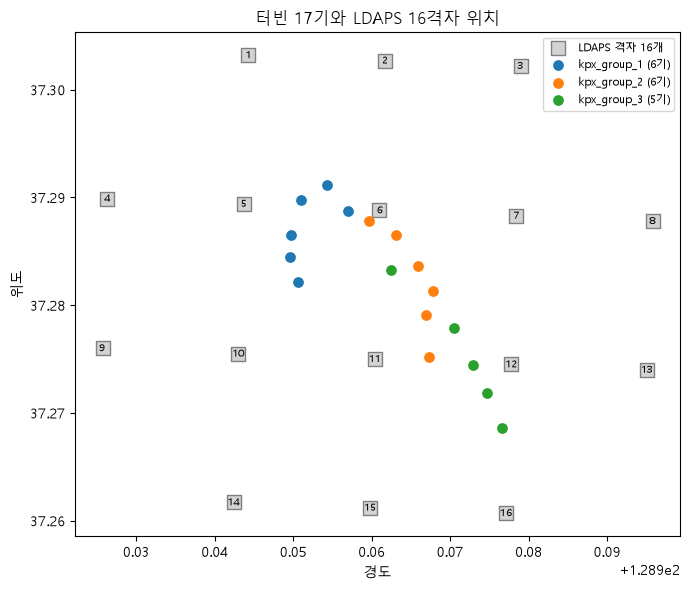

In [39]:
spatial_mapper = LDAPSSpatialMapper()

grid_coords = ldaps.groupby("grid_id")[["latitude", "longitude"]].first().sort_index()
# 격자별 좌표. 기간 내내 고정임을 Step 1에서 확인했다
tmeta = turbine_meta.reset_index(drop=True)
# 행 순서를 고정해 아래 행렬 인덱스와 맞춘다

weight_table = spatial_mapper.computeGroupWeight(tmeta, grid_coords)
print("그룹별 격자 가중치 (행 합계 = 1). 그룹마다 다른 격자를 보고 있어야 이 작업이 의미가 있다")
print(weight_table)
print()
print("터빈에서 가장 가까운 격자까지의 거리(km):", np.round(spatial_mapper.distance.min(axis=1), 2).tolist())

spatial_mapper.plotGridMapping(tmeta)

In [40]:
# 격자별로 이미 계산해둔 파생변수를 그룹별로 공간 가중평균한다 (비선형 계산을 먼저 한 이유가 이것)
IDW_FEATURES = [
    "u10", "v10", "ws10", "air_density", "wind_power_density",
    # 바람·밀도·에너지
    "t2m", "dpt2m", "rh2m", "q2m", "t_dew_diff",
    # 기온·습도
    "sp", "prmsl", "blh", "surface_h", "blws",
    # 기압·경계층·고도
    "u50_range", "v50_range", "ws10_spatial_range",
    # 변동성
    "lcc", "mcc", "hcc", "vlcdc",
    # 운량
    "ncpcp", "ls_prate", "nd_sw", "nd_lw",
    # 강수·복사
]

ldaps_group_idw = spatial_mapper.transformToGroupFeature(ldaps, IDW_FEATURES)

# 풍향은 가중평균한 U·V에서 다시 복원한다 (각도를 직접 가중평균하면 안 된다)
ldaps_group_idw["ws10_vector"] = ldaps_preprocessor.computeWindSpeed(
    ldaps_group_idw["u10"], ldaps_group_idw["v10"]
)
ldaps_group_idw["wd10"] = ldaps_preprocessor.computeWindDirection(
    ldaps_group_idw["u10"], ldaps_group_idw["v10"]
)
ldaps_group_idw = ldaps_preprocessor.transformWindDirection(ldaps_group_idw, ["wd10"])
ldaps_group_idw["ws10_2"] = ldaps_group_idw["ws10"] ** 2
ldaps_group_idw["ws10_3"] = ldaps_group_idw["ws10"] ** 3
# 풍력에너지가 풍속 세제곱에 비례한다

print(f"그룹별 공간가중 LDAPS 피처: {len(ldaps_group_idw):,}행 x {ldaps_group_idw.shape[1]}열")
print()
print("그룹별 평균 - 세 그룹 값이 서로 달라야 공간 매핑이 의미가 있다")
print(ldaps_group_idw.groupby("group")[["ws10", "ws10_vector", "air_density", "surface_h"]].mean().round(4))

그룹별 공간가중 LDAPS 피처: 78,912행 x 34열

그룹별 평균 - 세 그룹 값이 서로 달라야 공간 매핑이 의미가 있다
               ws10  ws10_vector  air_density  surface_h
group                                                   
kpx_group_1  4.9039       4.8869       1.1154   993.4741
kpx_group_2  5.0767       5.0605       1.1156   988.4212
kpx_group_3  5.1344       5.1172       1.1176   968.2889


### Step 10-2. 비교용: 16격자 단순 통계 버전도 같이 만들기

10-1이 정말 나은지는 검증 성능으로 확인해야 한다. 그래서 지금까지 쓰던 **16격자 단순 통계** 버전도
나란히 만들어 저장한다.

평균만 넣지 않고 표준편차·최소·최대·분위수까지 넣어서, 06 문서 2.12의
"평균 풍속 8m/s 하나로는 전 격자 8m/s인 경우와 절반 4m/s·절반 12m/s인 경우를 구분할 수 없다"는 문제를 줄인다.

In [41]:
class LDAPSGridStatsBuilder:
    """16격자 단순 통계 버전 피처 생성을 담당하는 클래스

    Attributes:
        - 공간 가중(IDW) 버전과 A/B 비교하기 위한 대조군이다
    """

    STAT_FEATURES = [
        "ws10", "u10", "v10", "air_density", "wind_power_density",
        "t2m", "q2m", "sp", "blh", "rh2m", "lcc", "ncpcp",
    ]

    def __init__(self, transformer: WindVectorTransformer):
        self.transformer = transformer

    def transformToGridStats(self, ldaps: pd.DataFrame) -> pd.DataFrame:
        """시각별 16격자 통계를 계산하는 메서드

        Logic:
            - 세제곱 계열은 '격자별로 먼저 계산 -> 평균' 순서를 지킨다
              (평균 풍속을 세제곱한 값과 다르다. 젠센 부등식)
        """
        ldaps = ldaps.copy()
        ldaps["ws10_2"] = ldaps["ws10"] ** 2
        ldaps["ws10_3"] = ldaps["ws10"] ** 3
        ldaps["rho_ws3"] = ldaps["air_density"] * ldaps["ws10"] ** 3
        # 격자별로 먼저 계산해야 한다

        grouped = ldaps.groupby("forecast_kst_dtm")
        stats = {
            "mean": grouped[self.STAT_FEATURES].mean(),
            "std": grouped[self.STAT_FEATURES].std(),
            # 격자 간 표준편차 = 공간 변동성
            "min": grouped[self.STAT_FEATURES].min(),
            "max": grouped[self.STAT_FEATURES].max(),
        }
        grid_stats = pd.concat(stats, axis=1)
        grid_stats.columns = [f"ldaps_{col}_{stat}" for stat, col in grid_stats.columns]
        # ldaps_ws10_mean 형태로 이름 정리

        quantile = grouped["ws10"].quantile([0.25, 0.5, 0.75]).unstack()
        quantile.columns = ["ldaps_ws10_q25", "ldaps_ws10_median", "ldaps_ws10_q75"]
        grid_stats = grid_stats.join(quantile)

        grid_stats["ldaps_mean_ws2"] = grouped["ws10_2"].mean()
        grid_stats["ldaps_mean_ws3"] = grouped["ws10_3"].mean()
        grid_stats["ldaps_mean_rho_ws3"] = grouped["rho_ws3"].mean()
        grid_stats["ldaps_ws10_range"] = grid_stats["ldaps_ws10_max"] - grid_stats["ldaps_ws10_min"]

        grid_stats["ldaps_wd10"] = self.transformer.computeWindDirection(
            grid_stats["ldaps_u10_mean"], grid_stats["ldaps_v10_mean"]
        )
        # 풍향은 격자 U·V 평균에서 복원한다
        return grid_stats.reset_index()

In [42]:
grid_stats_builder = LDAPSGridStatsBuilder(ldaps_preprocessor)
ldaps_grid_stats = grid_stats_builder.transformToGridStats(ldaps)

cube_of_mean = ldaps_grid_stats["ldaps_ws10_mean"] ** 3
mean_of_cube = ldaps_grid_stats["ldaps_mean_ws3"]

print(f"16격자 단순 통계 버전: {ldaps_grid_stats.shape[0]:,}행 x {ldaps_grid_stats.shape[1]}열")
print()
print(f"(평균 풍속)³ 평균 = {cube_of_mean.mean():.1f}")
print(f"평균(풍속³)   평균 = {mean_of_cube.mean():.1f}")
print(f"-> 평균을 먼저 내면 발전 가능 에너지를 {(1 - cube_of_mean.mean() / mean_of_cube.mean()) * 100:.1f}% 과소평가한다")
print("   순서가 중요하다는 증거 (06 문서 2.12)")

16격자 단순 통계 버전: 26,304행 x 57열

(평균 풍속)³ 평균 = 216.0
평균(풍속³)   평균 = 227.2
-> 평균을 먼저 내면 발전 가능 에너지를 4.9% 과소평가한다
   순서가 중요하다는 증거 (06 문서 2.12)


### Step 10-3. 시간 정보와 예보 시간 변화량

발전량은 월별 패턴이 반복되니 계절 정보가 필요하고, 램프(급격한 증감) 구간을 잡으려면 변화량도 필요하다.

주의: 시(hour)와 연중일(day of year)은 순환값이라 그냥 숫자로 넣으면 23시와 0시가 멀리 떨어진 값이 된다.
sin·cos으로 넣는다.

In [43]:
class TimeFeatureEngineer:
    """시간 순환 인코딩과 예보 변화량 파생을 담당하는 클래스

    Attributes:
        - 변화량은 반드시 그룹별로 따로 계산해야 한다. 안 그러면 그룹 경계에서 엉뚱한 차이가 생긴다
    """

    SEASON_MAP = {0: "winter", 1: "spring", 2: "summer", 3: "autumn"}
    # (월 % 12) // 3 결과를 계절 이름으로. 12·1·2월이 winter가 된다

    def __init__(self, transformer: WindVectorTransformer):
        self.transformer = transformer

    def transformCyclicTime(self, df: pd.DataFrame, time_col: str = "forecast_kst_dtm") -> pd.DataFrame:
        """시각에서 순환 인코딩된 시간 피처를 만드는 메서드

        Logic:
            - 하루 주기와 1년 주기를 각각 원으로 펴서 23시와 0시, 12월 31일과 1월 1일이 붙어있게 한다
        """
        df = df.copy()
        dt = df[time_col]
        df["hour_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)
        df["hour_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)
        df["doy_sin"] = np.sin(2 * np.pi * dt.dt.dayofyear / 365.25)
        df["doy_cos"] = np.cos(2 * np.pi * dt.dt.dayofyear / 365.25)
        df["month"] = dt.dt.month
        df["season"] = (dt.dt.month % 12 // 3).map(self.SEASON_MAP)
        return df

    def transformForecastDiff(self, df: pd.DataFrame, key: str = "group") -> pd.DataFrame:
        """예보 시계열의 변화량·램프 피처를 만드는 메서드

        Logic:
            - 01:00 자료의 '1시간 전'은 전날 발행분의 마지막 시각이다.
              대상 시각은 연속이지만 발행분은 다르므로 lead_hour를 남겨 나중에 따로 취급할 수 있게 한다
        """
        df = df.copy()
        by_group = df.groupby(key, observed=True)

        df["ws_diff_1h"] = by_group["ws10"].diff(1)
        df["ws_diff_3h"] = by_group["ws10"].diff(3)
        df["u_diff_1h"] = by_group["u10"].diff(1)
        df["v_diff_1h"] = by_group["v10"].diff(1)
        df["ws_next3h_max"] = by_group["ws10"].transform(lambda s: s.shift(-1).rolling(3, min_periods=1).max())
        df["ws_next3h_min"] = by_group["ws10"].transform(lambda s: s.shift(-1).rolling(3, min_periods=1).min())
        df["ws_ramp_rate"] = df["ws_diff_1h"].abs()
        # 풍속 램프율 (변화 속도)
        df["wd_rotation"] = self.transformer.computeAngleDifference(
            by_group["wd10"].shift(0), by_group["wd10"].shift(1)
        ).abs()
        # 풍향 회전속도. -180~180으로 감은 뒤 절댓값
        return df

In [44]:
time_engineer = TimeFeatureEngineer(ldaps_preprocessor)

feat = ldaps_group_idw.sort_values(["group", "forecast_kst_dtm"], ignore_index=True)
# 그룹별 시간순 정렬은 변화량 계산 전에 필수다

time_meta = ldaps.groupby("forecast_kst_dtm")[["lead_hour", "target_hour", "forecast_issue_date"]].first().reset_index()
feat = feat.merge(time_meta, on="forecast_kst_dtm", how="left")
# 예보 시간 메타를 다시 붙인다 (격자마다 같으니 시각 단위로 하나만 꺼내온다)

feat = time_engineer.transformCyclicTime(feat)
feat = time_engineer.transformForecastDiff(feat)

print(f"시간 파생 추가 후: {len(feat):,}행 x {feat.shape[1]}열")
print()
print("계절별 평균 풍속 (겨울에 높고 늦여름에 낮은 패턴이 나와야 01 노트북 결과와 맞다)")
print(feat.groupby(["season", "group"], observed=True)["ws10"].mean().unstack().round(3))

시간 파생 추가 후: 78,912행 x 51열

계절별 평균 풍속 (겨울에 높고 늦여름에 낮은 패턴이 나와야 01 노트북 결과와 맞다)
group   kpx_group_1  kpx_group_2  kpx_group_3
season                                       
autumn        4.407        4.490        4.501
spring        5.142        5.297        5.345
summer        4.402        4.473        4.461
winter        5.673        6.058        6.244


In [45]:
# LDAPS 예보 대상 시각(forecast_kst_dtm)과 SCADA 시간 칸(hour_end)을 맞춰 붙인다
# 둘 다 '1시간 집계 종료 시각' 기준이라 이름만 다르고 같은 의미다
train_merged = feat.merge(
    scada_group_hourly.rename(columns={"hour_end": "forecast_kst_dtm"}),
    on=["forecast_kst_dtm", "group"], how="left",
    # 예보 시각 전체를 기준으로 왼쪽 결합 (SCADA가 없는 구간은 NaN)
)
train_merged = train_merged.merge(ldaps_grid_stats, on="forecast_kst_dtm", how="left")
# 16격자 단순 통계 버전도 같은 표에 붙인다 (컬럼 이름이 ldaps_로 시작해 구분된다)

print(f"최종 결합표: {len(train_merged):,}행 x {train_merged.shape[1]}열")
print(f"기간: {train_merged['forecast_kst_dtm'].min()} ~ {train_merged['forecast_kst_dtm'].max()}")
print()
print("그룹별 SCADA 결합 상황 (그룹3은 2023년부터라 결측이 많은 게 정상)")
print(train_merged.groupby("group", observed=True).agg(
    행수=("forecast_kst_dtm", "size"),
    SCADA있음=("scada_power_kwh", "count"),
    SCADA결측=("scada_power_kwh", lambda s: int(s.isna().sum())),
))

최종 결합표: 78,912행 x 120열
기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00

그룹별 SCADA 결합 상황 (그룹3은 2023년부터라 결측이 많은 게 정상)
                행수  SCADA있음  SCADA결측
group                               
kpx_group_1  26304    26179      125
kpx_group_2  26304    26243       61
kpx_group_3  26304    16343     9961


> **주의: SCADA 컬럼(`scada_*`)은 최종 모델 입력이 아니다**
>
> 평가 기간에는 LDAPS와 GFS만 제공되고 SCADA는 없다. `scada_ws_scalar` 같은 걸 학습표에 그냥 넣으면
> 학습 성능은 아주 좋아지지만 테스트에서는 그 값을 만들 수가 없다.
>
> 그래서 이 표의 SCADA 컬럼은 다음 용도로만 쓴다.
> - LDAPS 10m 풍속 → 현장 허브 높이 풍속 **보정 모델의 정답값**
> - 파워커브 추정, 이상 상태 분석
>
> 그리고 그 보정 모델을 주 모델 입력으로 쓸 때는 학습 구간에 **Out-of-Fold 예측값**을 만들어야 한다.
> 전체 기간으로 학습한 보정 모델로 같은 기간을 다시 예측하면 간접 누수가 생긴다.

### Step 10-4. 전처리 검증

`train_labels.csv`는 이 노트북의 전처리 대상이 아니라서 가공하지 않고 **검증용 참조로만** 한 번 읽는다.
(최종 학습 정답은 항상 공식 라벨을 쓰는 게 맞지만 그건 다음 모델링 노트북에서 할 일이다)

확인할 것

- `ceil` 기준으로 만든 시간 칸이 공식 라벨과 정말 맞는지 (±1시간 밀리면 성능 상한이 크게 낮아진다)
- 그룹3의 2022년이 0으로 채워지지 않고 비어 있는지
- 공기밀도가 현실 범위인지

In [46]:
class PreprocessingValidator(CheckCollector):
    """전처리 결과가 공식 라벨·물리 상식과 맞는지 확인하는 클래스

    Attributes:
        - 시각이 ±1시간 밀리면 뒤 모델의 성능 상한이 통째로 낮아지므로 여기서 반드시 잡는다
    """

    def checkTimeAlignment(
        self,
        group_hourly: pd.DataFrame,
        labels_long: pd.DataFrame,
        shifts: List[int] = (-1, 0, 1),
    ) -> pd.DataFrame:
        """시간 칸을 앞뒤로 밀어보며 공식 라벨과 가장 잘 맞는 지점을 찾는 메서드

        Logic:
            - '+0시간'의 MAE가 가장 작아야 우리 ceil 규칙이 맞다는 뜻이다
            - 이동이 0이 아닐 때 더 좋게 나오면 시간 칸이 밀린 것이므로 Step 2부터 다시 봐야 한다
        """
        align_rows = []
        for shift in shifts:
            moved = group_hourly[["hour_end", "group", "scada_power_kwh"]].copy()
            moved["kst_dtm"] = moved["hour_end"] + pd.Timedelta(hours=shift)
            compared = moved.merge(labels_long, on=["kst_dtm", "group"], how="inner").dropna(
                subset=["scada_power_kwh", "label_kwh"]
            )
            for group, part in compared.groupby("group", observed=True):
                align_rows.append({
                    "그룹": group,
                    "시각 이동": f"{shift:+d}시간",
                    "비교 행수": len(part),
                    "MAE(kWh)": round((part["scada_power_kwh"] - part["label_kwh"]).abs().mean(), 1),
                    "상관계수": round(part["scada_power_kwh"].corr(part["label_kwh"]), 4),
                    "SCADA÷라벨 중앙값": round(
                        (part["scada_power_kwh"] / part["label_kwh"].replace(0, np.nan)).median(), 4
                    ),
                })
        return pd.DataFrame(align_rows).sort_values(["그룹", "시각 이동"])

    def checkFinalOutput(self, train_merged: pd.DataFrame, align_report: pd.DataFrame) -> pd.DataFrame:
        """최종 결합표가 기대한 모양·범위인지 한 번에 확인하는 메서드"""
        best = align_report.loc[align_report.groupby("그룹")["MAE(kWh)"].idxmin()]
        self.addCheck("전체", "시각 정합(+0시간이 최적)", bool((best["시각 이동"] == "+0시간").all()),
                      f"그룹별 최적 이동 = {best['시각 이동'].tolist()}")

        g3_2022 = train_merged[
            (train_merged["group"] == "kpx_group_3") & (train_merged["forecast_kst_dtm"].dt.year == 2022)
        ]
        self.addCheck("전체", "그룹3 2022년이 비어 있음", bool(g3_2022["scada_power_kwh"].isna().all()),
                      f"2022년 {len(g3_2022)}행 전부 NaN (0으로 채우지 않았음)")

        self.addCheck("전체", "공기밀도 0.9~1.4 kg/m³",
                      bool(train_merged["air_density"].between(0.9, 1.4).all()),
                      f"{train_merged['air_density'].min():.4f} ~ {train_merged['air_density'].max():.4f}")

        expected_rows = train_merged["forecast_kst_dtm"].nunique() * len(GROUPS)
        self.addCheck("전체", "행 수 = 시각x그룹", len(train_merged) == expected_rows,
                      f"{len(train_merged):,}행 (기대 {expected_rows:,})")

        self.addCheck("전체", "(시각, 그룹) 중복 없음",
                      not bool(train_merged.duplicated(["forecast_kst_dtm", "group"]).any()),
                      "결합 과정에서 행이 불어나지 않음")

        ws_by_group = train_merged.groupby("group", observed=True)["ws10"].mean()
        self.addCheck("전체", "그룹별 LDAPS 풍속이 서로 다름", ws_by_group.nunique() == len(GROUPS),
                      f"{ws_by_group.round(4).to_dict()}")
        # 세 그룹 값이 같으면 공간 가중이 적용되지 않은 것이다

        self.addCheck("전체", "설비이용률 <= 105%",
                      bool((train_merged["capacity_factor"].dropna() <= 1.05).all()),
                      f"최대 {train_merged['capacity_factor'].max():.3f}")

        return self.summarize()

In [47]:
labels_ref = loader["train_labels"].copy()
# 검증용 참조. 가공하지 않는다
labels_ref["kst_dtm"] = pd.to_datetime(labels_ref["kst_dtm"])
labels_long = labels_ref.melt(
    id_vars="kst_dtm", value_vars=GROUPS, var_name="group", value_name="label_kwh"
)

validator = PreprocessingValidator()
align_report = validator.checkTimeAlignment(scada_group_hourly, labels_long)

print("시각 정합 검사: '+0시간'의 MAE가 가장 작아야 우리 ceil 규칙이 맞다는 뜻이다")
align_report

시각 정합 검사: '+0시간'의 MAE가 가장 작아야 우리 ceil 규칙이 맞다는 뜻이다


,그룹,시각 이동,비교 행수,MAE(kWh),상관계수,SCADA÷라벨 중앙값
3,kpx_group_1,+0시간,26075,130.9,0.9998,1.0148
6,kpx_group_1,+1시간,26074,1202.1,0.9598,1.0055
0,kpx_group_1,-1시간,26075,1273.1,0.9549,1.0082
4,kpx_group_2,+0시간,26140,124.7,0.9998,1.0110
7,kpx_group_2,+1시간,26139,1185.3,0.9646,1.0039
1,kpx_group_2,-1시간,26140,1266.7,0.9597,1.0047
5,kpx_group_3,+0시간,16343,282.3,0.9967,0.9963
8,kpx_group_3,+1시간,16342,1020.5,0.9559,0.9860
2,kpx_group_3,-1시간,16342,1332.5,0.9261,0.9666


In [48]:
final_report = validator.checkFinalOutput(train_merged, align_report)
print("최종 검증")
final_report

최종 검증


,대상,검사항목,통과,내용
0,전체,시각 정합(+0시간이 최적),O,"그룹별 최적 이동 = ['+0시간', '+0시간', '+0시간']"
1,전체,그룹3 2022년이 비어 있음,O,2022년 8759행 전부 NaN (0으로 채우지 않았음)
2,전체,공기밀도 0.9~1.4 kg/m³,O,1.0232 ~ 1.2543
3,전체,행 수 = 시각x그룹,O,"78,912행 (기대 78,912)"
4,전체,"(시각, 그룹) 중복 없음",O,결합 과정에서 행이 불어나지 않음
5,전체,그룹별 LDAPS 풍속이 서로 다름,O,"{'kpx_group_1': 4.9039, 'kpx_group_2': 5.0767,..."
6,전체,설비이용률 <= 105%,O,최대 1.004


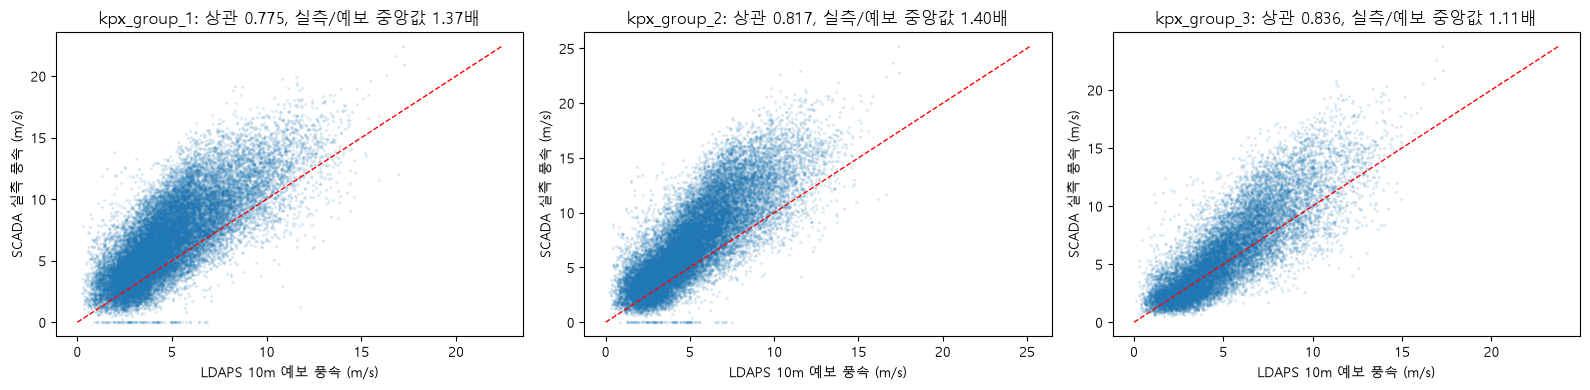

In [49]:
# 마지막으로 눈으로 확인: LDAPS 예보 풍속과 SCADA 실측 풍속이 얼마나 닮았나
# '10m 예보풍속 -> 허브 높이(117m) 현장풍속 보정'이 다음 과제라는 걸 여기서 확인할 수 있다
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, group in zip(axes, GROUPS):
    part = train_merged[train_merged["group"] == group].dropna(subset=["scada_ws_scalar", "ws10"])
    ax.scatter(part["ws10"], part["scada_ws_scalar"], s=2, alpha=0.1)
    lim = [0, max(part["ws10"].max(), part["scada_ws_scalar"].max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    # 기울기 1인 참조선. 여기 붙어있으면 보정이 필요 없다는 뜻이다
    corr = part["ws10"].corr(part["scada_ws_scalar"])
    ratio = (part["scada_ws_scalar"] / part["ws10"].replace(0, np.nan)).median()
    ax.set_title(f"{group}: 상관 {corr:.3f}, 실측/예보 중앙값 {ratio:.2f}배")
    ax.set_xlabel("LDAPS 10m 예보 풍속 (m/s)")
    ax.set_ylabel("SCADA 실측 풍속 (m/s)")
plt.tight_layout()
plt.show()

## Step 11. prep/ 폴더에 저장

다음(모델링) 노트북이 바로 받아쓸 수 있게 CSV로 저장한다.

- 10분 단위 표는 240만 행이라 그대로 쓰면 파일이 너무 커진다 → gzip으로 압축
- `float_format`을 안 주면 소수점이 17자리까지 찍혀 파일이 두 배 넘게 커진다.
  유효숫자 6자리면 기상값·발전량 모두 충분하다

In [50]:
class PreprocessedDataWriter:
    """전처리 결과를 prep/ 폴더에 저장하는 것을 담당하는 클래스

    Attributes:
        - float_format : 유효숫자 6자리. 안 주면 파일 크기가 두 배 넘게 커진다
        - 확장자가 .gz면 pandas가 알아서 압축한다
    """

    def __init__(self, prep_dir: Path = PREP_DIR, encoding: str = "utf-8-sig", float_format: str = "%.6g"):
        self.prep_dir = prep_dir
        self.encoding = encoding
        self.float_format = float_format

    def save(self, outputs: Dict[str, pd.DataFrame]) -> None:
        """이름 -> DataFrame 딕셔너리를 한 번에 저장하는 메서드"""
        for fname, df in outputs.items():
            path = self.prep_dir / fname
            df.to_csv(path, index=False, encoding=self.encoding, float_format=self.float_format)
            print(f"{fname}: {len(df):,}행 x {df.shape[1]}열, {path.stat().st_size / 1e6:.1f} MB")

    def saveQcReport(self, reports: List[pd.DataFrame], fname: str = "qc_report.csv") -> pd.DataFrame:
        """여러 검사 표를 하나로 묶어 저장하는 메서드

        Logic:
            - 전처리 근거를 파일로 남겨두면 나중에 "왜 이 값을 지웠나"를 되짚을 수 있다
        """
        qc_report = pd.concat(reports, ignore_index=True)[["구분", "대상", "검사항목", "통과", "내용"]]
        qc_report.to_csv(self.prep_dir / fname, index=False, encoding=self.encoding)
        print(f"{fname}: {len(qc_report)}행")
        return qc_report

    def checkReload(self, fname: str, parse_dates: List[str]) -> pd.DataFrame:
        """저장한 파일을 다시 읽어 다음 노트북이 바로 쓸 수 있는 상태인지 확인하는 메서드"""
        reloaded = pd.read_csv(self.prep_dir / fname, encoding=self.encoding, parse_dates=parse_dates)
        print(f"다시 읽은 {fname}: {len(reloaded):,}행 x {reloaded.shape[1]}열")
        print(f"결측률이 50%를 넘는 컬럼: {[c for c in reloaded.columns if reloaded[c].isna().mean() > 0.5]}")
        return reloaded

In [51]:
writer = PreprocessedDataWriter()

TURBINE_10MIN_COLS = [
    "kst_dtm", "hour_end", "turbine", "group", "power_raw", "power_clean", "power_filled",
    "ws_raw", "ws_clean", "ws_filled", "wd_raw", "wd_clean", "u_scada", "v_scada",
    "power_qc_flag", "n_valid_in_hour", "na_run_len", "is_power_interpolated",
] + ScadaPreprocessor.FLAG_COLS
# 원본·정제·플래그를 모두 남겨 나중에 되돌려 볼 수 있게 한다

writer.save({
    "scada_turbine_10min.csv.gz": scada[TURBINE_10MIN_COLS],
    # 터빈 단위 10분 정제값 + QC 플래그
    "scada_turbine_hourly.csv": agg_turbine,
    # 터빈 단위 시간별 집계
    "scada_group_hourly.csv": scada_group_hourly,
    # 그룹 단위 시간별 발전량·풍속·풍향 + coverage
    "ldaps_group_idw.csv": ldaps_group_idw,
    # 그룹별 공간가중(IDW) LDAPS 피처
    "ldaps_grid_stats.csv": ldaps_grid_stats,
    # 16격자 단순 통계 버전 (비교용)
    "train_merged.csv": train_merged,
    # 최종 결합표
})

scada_turbine_10min.csv.gz: 2,420,148행 x 27열, 63.4 MB
scada_turbine_hourly.csv: 403,368행 x 19열, 56.3 MB
scada_group_hourly.csv: 78,912행 x 15열, 8.9 MB
ldaps_group_idw.csv: 78,912행 x 34열, 21.5 MB
ldaps_grid_stats.csv: 26,304행 x 57열, 12.0 MB
train_merged.csv: 78,912행 x 120열, 72.5 MB


In [52]:
qc_report = writer.saveQcReport([
    contract_report.assign(구분="Step 1 데이터 계약 검사"),
    ldaps_qc_report.assign(구분="Step 4 LDAPS 품질검사"),
    final_report.assign(구분="Step 10 최종 검증"),
])

print(f"\nprep/ 폴더 총 용량: {sum(f.stat().st_size for f in PREP_DIR.glob('*')) / 1e6:.0f} MB")
print("(git에 올릴 생각이면 prep/은 .gitignore에 넣는 걸 권한다. 코드만 있으면 언제든 다시 만들 수 있다)")

writer.checkReload("train_merged.csv", parse_dates=["forecast_kst_dtm"])

qc_report.csv: 26행

prep/ 폴더 총 용량: 235 MB
(git에 올릴 생각이면 prep/은 .gitignore에 넣는 걸 권한다. 코드만 있으면 언제든 다시 만들 수 있다)
다시 읽은 train_merged.csv: 78,912행 x 120열
결측률이 50%를 넘는 컬럼: []


,forecast_kst_dtm,group,u10,v10,ws10,air_density,wind_power_density,t2m,dpt2m,rh2m,q2m,t_dew_diff,sp,prmsl,blh,surface_h,blws,u50_range,v50_range,ws10_spatial_range,lcc,mcc,hcc,vlcdc,ncpcp,...,ldaps_sp_min,ldaps_blh_min,ldaps_rh2m_min,ldaps_lcc_min,ldaps_ncpcp_min,ldaps_ws10_max,ldaps_u10_max,ldaps_v10_max,ldaps_air_density_max,ldaps_wind_power_density_max,ldaps_t2m_max,ldaps_q2m_max,ldaps_sp_max,ldaps_blh_max,ldaps_rh2m_max,ldaps_lcc_max,ldaps_ncpcp_max,ldaps_ws10_q25,ldaps_ws10_median,ldaps_ws10_q75,ldaps_mean_ws2,ldaps_mean_ws3,ldaps_mean_rho_ws3,ldaps_ws10_range,ldaps_wd10
0,2022-01-01 01:00:00,kpx_group_1,5.46595,0.595273,5.51780,1.21199,106.2230,260.395,246.582,34.7489,0.000488,13.81220,90618.2,102666.0,172.343,993.474,0.096328,0.634080,0.288014,3.63465,0.0,0.0,0.103045,0.0,0.0,...,90511.9,144.323,26.2933,0.0,0.0,6.68327,6.60990,1.591680,1.22910,181.535,262.595,0.000488,92078.4,204.948,39.8344,0.0,0.0,4.81719,5.64044,6.22101,29.9473,172.2220,209.221,3.63465,271.875
1,2022-01-01 02:00:00,kpx_group_1,4.66050,0.388641,4.68881,1.21024,64.3130,260.902,246.160,32.1538,0.000488,14.74230,90663.5,102706.0,187.935,993.474,0.067659,1.622970,0.827560,3.78463,0.0,0.0,0.155100,0.0,0.0,...,90560.6,143.969,25.9218,0.0,0.0,5.97179,5.82315,0.937643,1.23008,129.426,262.712,0.000681,92135.1,203.032,48.8633,0.0,0.0,4.04376,4.53621,5.18958,21.1230,103.3400,125.417,3.78463,275.354
2,2022-01-01 03:00:00,kpx_group_1,4.38706,0.617841,4.44916,1.20863,54.9296,261.243,245.754,29.9737,0.000488,15.48860,90661.7,102685.0,187.949,993.474,0.048273,0.727759,0.376644,3.46060,0.0,0.0,0.157995,0.0,0.0,...,90560.6,160.240,23.8622,0.0,0.0,5.69421,5.58133,1.183830,1.22900,111.983,262.966,0.000585,92131.6,203.052,46.5673,0.0,0.0,3.98498,4.38598,5.06997,19.5139,91.4346,110.819,3.46060,272.880
3,2022-01-01 04:00:00,kpx_group_1,4.59091,0.902151,4.69494,1.20594,65.1151,261.728,245.155,27.3867,0.000488,16.57230,90627.7,102627.0,187.943,993.474,0.068523,0.364415,0.350902,3.55025,0.0,0.0,0.140625,0.0,0.0,...,90524.8,160.227,20.5356,0.0,0.0,5.91585,5.87287,1.502130,1.22797,125.283,263.702,0.000585,92087.3,203.040,43.7094,0.0,0.0,4.13079,4.81168,5.31122,21.9868,109.1770,131.997,3.55025,268.118
4,2022-01-01 05:00:00,kpx_group_1,4.41853,0.878147,4.52207,1.20461,58.0303,262.020,244.780,25.6344,0.000488,17.23990,90628.8,102612.0,187.935,993.474,0.085715,0.436360,0.088793,3.62079,0.0,0.0,0.124788,0.0,0.0,...,90527.1,160.250,19.2232,0.0,0.0,5.67782,5.62860,1.504510,1.22762,110.557,264.102,0.000681,92087.1,203.062,47.7017,0.0,0.0,3.98207,4.60871,5.10493,20.1311,96.1137,116.027,3.62079,268.307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78907,2024-12-31 20:00:00,kpx_group_3,6.40754,0.884517,6.49019,1.18271,163.8230,265.496,258.087,59.6280,0.001257,7.40958,90204.2,101775.0,180.299,968.289,0.122611,0.247304,0.475473,4.32248,0.0,0.0,0.000000,0.0,0.0,...,89836.4,138.741,49.2149,0.0,0.0,6.98181,6.97931,2.853510,1.19345,202.350,266.975,0.001465,91344.9,253.303,65.3028,0.0,0.0,4.39725,5.97916,6.52548,31.9100,193.1660,228.980,4.32248,256.308
78908,2024-12-31 21:00:00,kpx_group_3,6.44546,1.071250,6.55966,1.18355,170.6220,265.386,257.776,58.7689,0.001257,7.60953,90230.6,101803.0,187.893,968.289,0.167284,0.332189,0.278015,5.41467,0.0,0.0,0.000000,0.0,0.0,...,89861.9,142.476,47.1767,0.0,0.0,7.64972,7.63269,3.125280,1.19536,266.137,267.043,0.001465,91364.9,264.164,68.1494,0.0,0.0,4.18359,5.81731,6.88894,32.5767,204.0100,242.039,5.41467,254.960
78909,2024-12-31 22:00:00,kpx_group_3,5.81590,0.294122,5.86134,1.18437,121.4610,265.279,257.386,57.4683,0.001221,7.89264,90254.7,101832.0,166.725,968.289,0.135871,0.784731,0.959875,5.19472,0.0,0.0,0.000000,0.0,0.0,...,89884.5,122.991,46.9706,0.0,0.0,6.84451,6.84418,2.673600,1.19719,190.774,266.850,0.001465,91399.5,255.678,70.2459,0.0,0.0,3.72182,5.26849,6.15948,26.2873,149.0640,177.009,5.194

## Step 12. 정리

**확정**

- 시간 규칙: SCADA 10분값은 `ceil("1h")`로 묶고 **합계**(÷6 아님)를 쓴다.
  Step 10-4 정합 검사에서 `+0시간`이 최적으로 나오는 것을 확인
- 단위: LDAPS 기온 **K**, 비습 **kg/kg**, 기압 **Pa**. 04 문서의 공기밀도 식을 그대로 적용 가능
- LDAPS 구조: 매 시각 16격자, 중복 없음, 사용 가능 시각은 13시, 선행시간 12~35시간
- SCADA 10분 시간축은 VESTAS·UNISON 둘 다 누락 없음

**개선**

1. `sum(axis=1)`에 `min_count` 추가 → Step 9. 결측이 발전량 0으로 바뀌는 사고를 막았다
2. 16격자 단순 평균을 그룹별 거리 가중으로 변경 → Step 10-1. 단순평균 버전도 같이 저장해 비교
3. 풍향 각도 평균 대신 U·V 집계 후 방향 복원 → Step 8-1·9
4. SCADA를 최종 모델 입력에서 빼고 LDAPS 보정용으로 재정의 → Step 10-3 주의 문구
5. `power/ws³` 효율은 참고용으로만. 파워커브 잔차 기반 효율은 모델링 노트북에서 → Step 8-1

**모델링에서 A/B로 비교할 것**

- `ldaps_group_idw`(공간가중) vs `ldaps_grid_stats`(16격자 단순통계) — 어느 쪽이 검증 성능이 좋은지
- `scada_power_kwh`(6/6 엄격) vs `scada_power_kwh_relaxed`(5/6 허용) — 보정 모델 학습 정답으로 어느 쪽이 나은지
- `coverage_ratio`가 낮은 시간을 학습에서 뺄지 말지
- 목표값을 발전량 그대로 쓸지 `capacity_factor`(설비용량 정규화)로 쓸지

**아직 남은 일**

- 10m 예보풍속 → 허브 높이(117m) 현장풍속 보정
- 그룹별 정상 파워커브 추정 후 `power_residual = 실제 - 기대`로 후류 효과 판단
- GFS 데이터는 이번 범위에서 제외했다. 80m·100m 바람이 허브 높이에 더 가까우니 나중에 추가할 만하다
- 검증은 상관계수가 아니라 대회 지표인 **1-NMAE**와 **FICR**로. 최종 예측은 `clip(0, 그룹 설비용량)` 필수